<a href="https://colab.research.google.com/github/Shrideshi1/multi-label-email-risk-detection/blob/main/notebooks/04_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- 04_evaluation.ipynb

1. Load processed features
2. Feature Analysis      <-- Add here
3. Model Comparison
4. Neural Network Evaluation
5. Visualizations
6. Discussion -->

 04_evaluation.ipynb --- Notebook Structure

1. Load Saved Outputs
- Test features and labels
- Five saved models
- Five saved prediction outputs

2. Feature Analysis
- TF-IDF vocabulary
- Metadata features
- Rule-based features
- Feature visualizations
- Test label distribution

3. Overall Model Comparison
- Classification reports
- Comparison table
- Accuracy/F1 comparison
- Hamming Loss comparison

4. Per-Class Evaluation
- Precision
- Recall
- F1
- Cross-model visualizations

5. Confusion Matrices
- Multilabel confusion matrices
- False-negative comparison

6. Individual Model Analysis
      - Logistic Regression Analysis
         - Model architecture / coefficients
         - Overall performance
         - Per-class performance
         - Risk category metrics visualization
         - Confusion analysis
         - False-negative analysis
         - Error summary
         - Prediction probability + BCE loss
         - Final summary

      - Random Forest Analysis
         - Model information
         - Overall metrics
         - Per-class metrics
         - Risk category performance plot
         - Confusion analysis
         - False-negative analysis
         - Error summary
         - Feature importance
         - Final summary

      - XGBoost Analysis
          - Model information
          - Feature importance analysis
          - Overall performance
          - Per-class performance
          - Risk category performance plot
          - Confusion analysis
          - False-negative analysis
          - Error summary
          - Final summary

      - SVM Analysis
           - Model information
           - Overall performance
           - Per-class metrics
           - Risk category performance plot
           - Confusion analysis
           - False-negative analysis
           - Error summary
           - Final summary

      - Neural Network Analysis
          - Model architecture
          - Overall performance
          - Per-class performance
          - Binary cross-entropy test loss
          - Test loss by risk category
          - False-negative analysis
          - False-positive analysis
          - Neural network summary
7. Cross-Model Deep Comparison
   - Neural Network vs XGBoost   
   - Best Model Comparison  
        - Best Weighted F1 model
        - Best Weighted Recall model
        - Best Micro F1 model
        - Best Macro F1 model
        - Lowest Hamming Loss model
        - Overall ranking table
   - Error Analysis Across Models
        - Total False Negatives by Model
        - Total False Positives by Model
        - Total Prediction Errors
        - Error Rate Comparison
        - Most Difficult Risk Categories
            - F1 Difficulty Table
            - Recall Difficulty Table
            - Interpretation
   - Best Model Summary
7. Final Discussion
    - Best weighted F1
    - Best weighted recall
    - Lowest Hamming Loss
    - Fewest false negatives


In [ ]:

# 1. Load Saved Outputs
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss

from google.colab import drive

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    classification_report,
    multilabel_confusion_matrix
)

drive.mount("/content/drive")

PROJECT_DIR = (
    "/content/drive/.shortcut-targets-by-id/"
    "1SLhiH7VulyiPZ7L846kJBEbN1pa4c4zU/"
    "Multi_Label_Email_Risk_Detection"
)

NOTEBOOKS_DIR = f"{PROJECT_DIR}/notebooks"
DATA_PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
FEATURE_DIR = f"{DATA_PROCESSED_DIR}/features"
MODELS_DIR = f"{PROJECT_DIR}/models"
REPORTS_DIR = f"{PROJECT_DIR}/reports"
FIGURES_DIR = f"{PROJECT_DIR}/figures"

os.chdir(PROJECT_DIR)
os.makedirs(REPORTS_DIR, exist_ok=True)

risk_cols = [
    "financial_risk",
    "credential_risk",
    "customer_info_risk",
    "proprietary_risk",
    "legal_risk",
    "attachment_risk",
    "phishing_spam_risk"
]

print("Current project folder:", os.getcwd())
print("Notebook files:", os.listdir(NOTEBOOKS_DIR))
print("Feature files:", os.listdir(FEATURE_DIR))
print("Model files:", os.listdir(MODELS_DIR))
print("Report files:", os.listdir(REPORTS_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current project folder: /content/drive/.shortcut-targets-by-id/1SLhiH7VulyiPZ7L846kJBEbN1pa4c4zU/Multi_Label_Email_Risk_Detection
Notebook files: ['01_data_preparation.ipynb', '02_feature_engineering.ipynb', '03_model_training.ipynb', '04_evaluation.ipynb']
Feature files: ['X_features.pkl', 'metadata_features.csv', 'y_labels.pkl', 'rule_features.csv', 'X_train_features.pkl', 'X_test_features.pkl', 'metadata_scaler.pkl', 'tfidf_vectorizer.pkl', 'y_test.pkl', 'y_train.pkl']
Model files: ['multi_label_email_risk_mlp.keras', 'random_forest_model.pkl', 'distilbert_email_risk', 'logistic_regression_model.pkl', 'xgboost_model.pkl', 'svm_model.pkl', 'mlp_model.pkl']
Report files: ['nn_overall_metrics.csv', 'nn_per_class_metrics.csv', 'model_comparison_results.csv', 'nn_binary_cross_entropy.csv', 'final_model_selection_summary.csv', 'false_negative_totals.csv', 'READM

In [ ]:
# Load Test Features and Labels


X_test = joblib.load(
    f"{FEATURE_DIR}/X_test_features.pkl"
)

Y_test = joblib.load(
    f"{FEATURE_DIR}/y_test.pkl"
)

Y_test = np.asarray(Y_test).astype(int)

print("Test feature shape:", X_test.shape)
print("Test label shape:", Y_test.shape)

Test feature shape: (13982, 10013)
Test label shape: (13982, 7)


In [ ]:
# Load Saved Models
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

distilbert_path = f"{MODELS_DIR}/distilbert_email_risk"

for model_name, model_path in {
    "Logistic Regression": f"{MODELS_DIR}/logistic_regression_model.pkl",
    "Random Forest": f"{MODELS_DIR}/random_forest_model.pkl",
    "SVM": f"{MODELS_DIR}/svm_model.pkl",
    "XGBoost": f"{MODELS_DIR}/xgboost_model.pkl",
    "Neural Network": f"{MODELS_DIR}/multi_label_email_risk_mlp.keras",
    "DistilBERT": distilbert_path
}.items():

    print(model_name, "exists:", os.path.exists(model_path))

models = {
    "Logistic Regression": joblib.load(
        f"{MODELS_DIR}/logistic_regression_model.pkl"
    ),

    "Random Forest": joblib.load(
        f"{MODELS_DIR}/random_forest_model.pkl"
    ),

    "SVM": joblib.load(
        f"{MODELS_DIR}/svm_model.pkl"
    ),

    "XGBoost": joblib.load(
        f"{MODELS_DIR}/xgboost_model.pkl"
    ),

    "Neural Network": tf.keras.models.load_model(
        f"{MODELS_DIR}/multi_label_email_risk_mlp.keras"
    ),

    "DistilBERT": AutoModelForSequenceClassification.from_pretrained(
        distilbert_path
    )
}

tokenizers = {
    "DistilBERT": AutoTokenizer.from_pretrained(
        distilbert_path
    )
}

print("Models loaded successfully:")
for model_name in models:
    print("-", model_name)

Logistic Regression exists: True
Random Forest exists: True
SVM exists: True
XGBoost exists: True
Neural Network exists: True
DistilBERT exists: True


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Models loaded successfully:
- Logistic Regression
- Random Forest
- SVM
- XGBoost
- Neural Network
- DistilBERT


In [ ]:
# ------------------------------------------------------------
# 2. Feature Analysis
# ------------------------------------------------------------


vectorizer_path = f"{FEATURE_DIR}/tfidf_vectorizer.pkl"
metadata_path = f"{FEATURE_DIR}/metadata_features.csv"
rule_features_path = f"{FEATURE_DIR}/rule_features.csv"

tfidf_vectorizer = joblib.load(vectorizer_path)
metadata_df = pd.read_csv(metadata_path)
rule_features_df = pd.read_csv(rule_features_path)

print("TF-IDF vocabulary size:",
      len(tfidf_vectorizer.get_feature_names_out()))

print("Metadata features:", metadata_df.shape)
print("Rule-based features:", rule_features_df.shape)

TF-IDF vocabulary size: 10000
Metadata features: (69910, 7)
Rule-based features: (69910, 6)


In [ ]:
# ------------------------------------------------------------
# TF-IDF Vocabulary Analysis
# ------------------------------------------------------------

tfidf_summary = pd.DataFrame({
    "Term": tfidf_vectorizer.get_feature_names_out(),
    "IDF": tfidf_vectorizer.idf_
})

# Lower IDF indicates terms appearing frequently across documents.
# Higher IDF indicates rarer terms that may provide stronger discrimination.
most_common_terms = tfidf_summary.sort_values(
    by="IDF",
    ascending=True
).head(20)

rarest_terms = tfidf_summary.sort_values(
    by="IDF",
    ascending=False
).head(20)

print("Most common TF-IDF terms:")
display(most_common_terms)

print("Rarest TF-IDF terms:")
display(rarest_terms)

Most common TF-IDF terms:


,Term,IDF
5473,number,1.593748
5837,number number,1.910834
9340,url,1.944791
2484,email,2.434066
8930,time,2.757747
5344,new,2.950534
9295,unsubscribe,2.974070
1385,com,3.081894
9898,wrote,3.158299
4581,list,3.177678


Rarest TF-IDF terms:


,Term,IDF
5329,net submission,10.545544
6027,number tied,10.545544
2435,edri,10.545544
9417,used bad,10.545544
1679,core win,10.545544
2507,email phishing,10.322400
7931,sender phishery,10.322400
3211,fuse filesystems,10.322400
5297,nbsp,10.322400
8243,space processes,10.322400


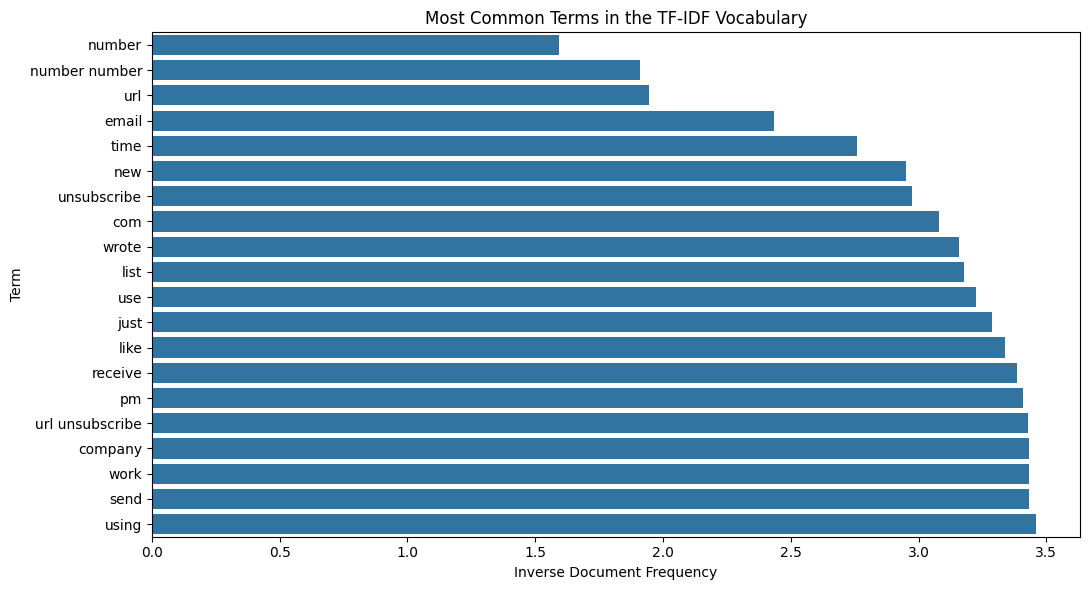

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=most_common_terms,
    x="IDF",
    y="Term"
)

plt.title("Most Common Terms in the TF-IDF Vocabulary")
plt.xlabel("Inverse Document Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Metadata Feature Analysis
# ------------------------------------------------------------

display(metadata_df.head())
display(metadata_df.describe().T)

,text_length,word_count,num_digits,num_dollar_signs,num_uppercase,num_exclamation,num_question
0,2896,590,32,1,0,0,0
1,1801,344,51,3,0,0,0
2,1486,287,60,0,0,1,0
3,329,61,0,0,0,0,1
4,1071,235,0,0,0,1,2


,count,mean,std,min,25%,50%,75%,max
text_length,69910.0,1056.722758,2942.954993,2.0,7.0,214.0,891.0,144051.0
word_count,69910.0,147.669218,421.480901,1.0,1.0,31.0,141.0,19873.0
num_digits,69910.0,41.663324,255.550875,0.0,0.0,4.0,24.0,11468.0
num_dollar_signs,69910.0,0.445387,4.886527,0.0,0.0,0.0,0.0,461.0
num_uppercase,69910.0,70.517952,274.973794,0.0,1.0,8.0,36.0,26777.0
num_exclamation,69910.0,0.669818,6.300292,0.0,0.0,0.0,0.0,414.0
num_question,69910.0,1.304434,4.742100,0.0,0.0,0.0,1.0,150.0


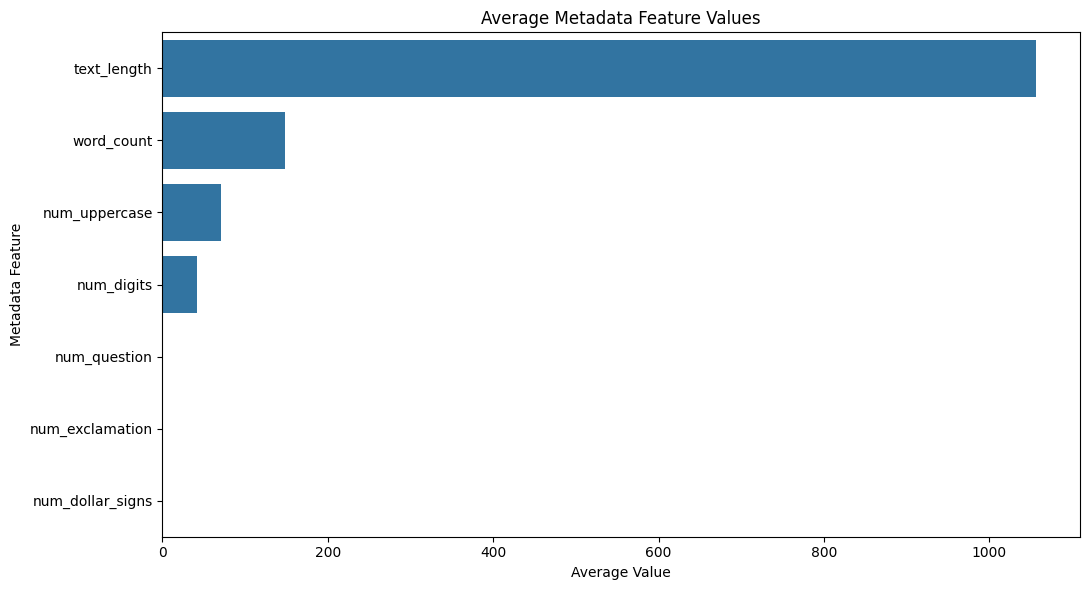

In [ ]:
metadata_numeric = metadata_df.select_dtypes(
    include=np.number
)

metadata_means = metadata_numeric.mean().sort_values(
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=metadata_means.values,
    y=metadata_means.index
)

plt.title("Average Metadata Feature Values")
plt.xlabel("Average Value")
plt.ylabel("Metadata Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Rule-Based Feature Analysis
# ------------------------------------------------------------

display(rule_features_df.head())
display(rule_features_df.describe().T)

,has_attachment_ext,has_money,has_credential_terms,has_customer_terms,has_legal_terms,has_internal_terms
0,0,1,1,0,1,0
1,0,1,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
has_attachment_ext,69910.0,0.029781,0.169984,0.0,0.0,0.0,0.0,1.0
has_money,69910.0,0.096066,0.294684,0.0,0.0,0.0,0.0,1.0
has_credential_terms,69910.0,0.055986,0.229897,0.0,0.0,0.0,0.0,1.0
has_customer_terms,69910.0,0.144271,0.351367,0.0,0.0,0.0,0.0,1.0
has_legal_terms,69910.0,0.149120,0.356210,0.0,0.0,0.0,0.0,1.0
has_internal_terms,69910.0,0.027149,0.162519,0.0,0.0,0.0,0.0,1.0


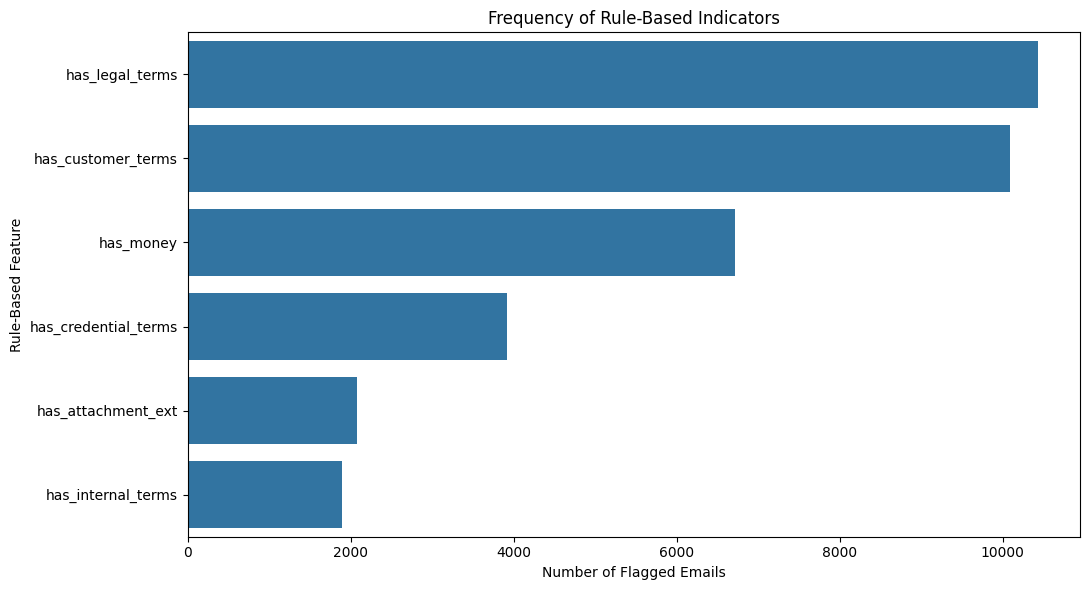

In [ ]:
rule_numeric = rule_features_df.select_dtypes(
    include=np.number
)

rule_counts = rule_numeric.sum().sort_values(
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=rule_counts.values,
    y=rule_counts.index
)

plt.title("Frequency of Rule-Based Indicators")
plt.xlabel("Number of Flagged Emails")
plt.ylabel("Rule-Based Feature")
plt.tight_layout()
plt.show()

,Risk Category,Positive Labels
0,phishing_spam_risk,4680
1,legal_risk,4269
2,financial_risk,803
3,customer_info_risk,360
4,credential_risk,358
5,attachment_risk,338
6,proprietary_risk,196


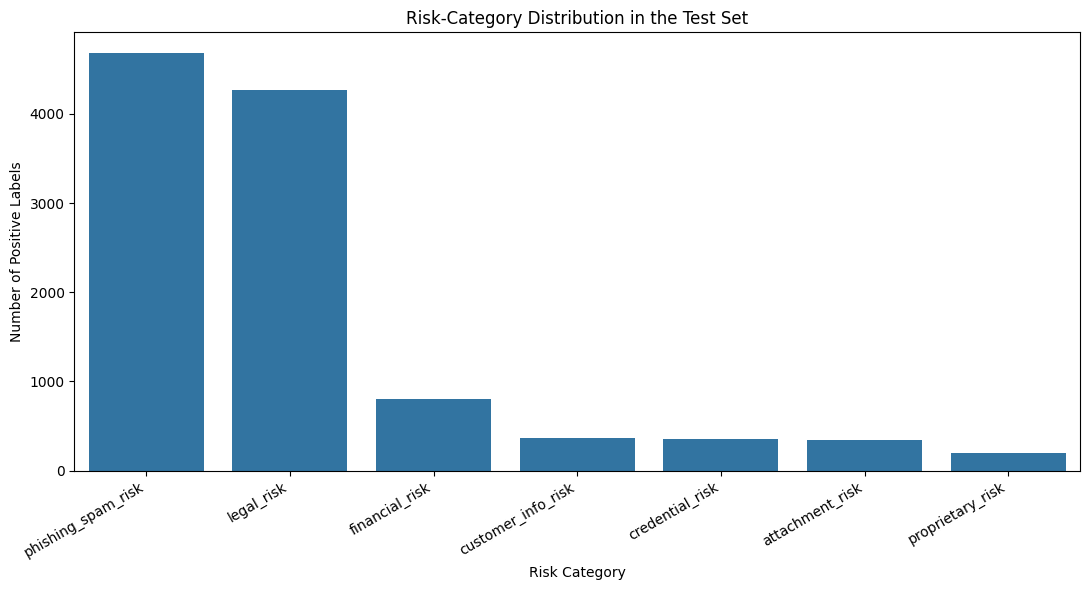

In [ ]:
label_counts = pd.Series(
    Y_test.sum(axis=0),
    index=risk_cols
).sort_values(ascending=False)

label_distribution_df = label_counts.reset_index()
label_distribution_df.columns = [
    "Risk Category",
    "Positive Labels"
]

display(label_distribution_df)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=label_distribution_df,
    x="Risk Category",
    y="Positive Labels"
)

plt.title("Risk-Category Distribution in the Test Set")
plt.xlabel("Risk Category")
plt.ylabel("Number of Positive Labels")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Load Saved Prediction Outputs
# ------------------------------------------------------------
prediction_files = {
    "Logistic Regression": "logistic_regression_predictions.pkl",
    "Random Forest": "random_forest_predictions.pkl",
    "SVM": "svm_predictions.pkl",
    "XGBoost": "xgboost_predictions.pkl",
    "Neural Network": "mlp_predictions.pkl"
}

# Recreate the dictionary so the old DistilBERT entry is removed
predictions = {}

for model_name, filename in prediction_files.items():

    prediction_path = f"{REPORTS_DIR}/{filename}"

    if not os.path.exists(prediction_path):
        raise FileNotFoundError(
            f"Missing prediction file: {prediction_path}"
        )

    preds = np.asarray(
        joblib.load(prediction_path)
    )

    if np.issubdtype(preds.dtype, np.floating):
        preds = (preds >= 0.50).astype(int)
    else:
        preds = preds.astype(int)

    if preds.shape != Y_test.shape:
        raise ValueError(
            f"{model_name}: prediction shape {preds.shape} "
            f"does not match test labels {Y_test.shape}"
        )

    predictions[model_name] = preds

print("Saved predictions loaded successfully:\n")

for model_name, preds in predictions.items():
    print(
        f"{model_name}: "
        f"shape={preds.shape}, "
        f"unique values={np.unique(preds)}"
    )

print("\nModels in predictions:", list(predictions.keys()))

# ------------------------------------------------------------
# 3. Overall Model Comparison
# ------------------------------------------------------------
overall_results = []

# Evaluate the five models whose predictions align with Y_test
for model_name, preds in predictions.items():

    overall_results.append({
        "Model": model_name,

        "Subset Accuracy": accuracy_score(
            Y_test,
            preds
        ),

        "Weighted Precision": precision_score(
            Y_test,
            preds,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            Y_test,
            preds,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            Y_test,
            preds,
            average="weighted",
            zero_division=0
        ),

        "Micro F1": f1_score(
            Y_test,
            preds,
            average="micro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            Y_test,
            preds,
            average="macro",
            zero_division=0
        ),

        "Hamming Loss": hamming_loss(
            Y_test,
            preds
        )
    })

# Add the valid DistilBERT metrics printed in Notebook 3
overall_results.append({
    "Model": "DistilBERT",
    "Subset Accuracy": np.nan,
    "Weighted Precision": np.nan,
    "Weighted Recall": 0.9927266115101373,
    "Weighted F1": 0.9944887317095135,
    "Micro F1": np.nan,
    "Macro F1": np.nan,
    "Hamming Loss": 0.0012362833847599976
})

comparison_df = pd.DataFrame(
    overall_results
)

comparison_df = comparison_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(
    comparison_df[
        [
            "Model",
            "Weighted F1",
            "Weighted Recall",
            "Hamming Loss"
        ]
    ].round(4)
)

Saved predictions loaded successfully:

Logistic Regression: shape=(13982, 7), unique values=[0 1]
Random Forest: shape=(13982, 7), unique values=[0 1]
SVM: shape=(13982, 7), unique values=[0 1]
XGBoost: shape=(13982, 7), unique values=[0 1]
Neural Network: shape=(13982, 7), unique values=[0 1]

Models in predictions: ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost', 'Neural Network']


,Model,Weighted F1,Weighted Recall,Hamming Loss
0,DistilBERT,0.9945,0.9927,0.0012
1,Random Forest,0.9928,0.9880,0.0016
2,Neural Network,0.9918,0.9927,0.0018
3,Logistic Regression,0.9903,0.9913,0.0022
4,XGBoost,0.9895,0.9862,0.0023
5,SVM,0.9828,0.9856,0.0038


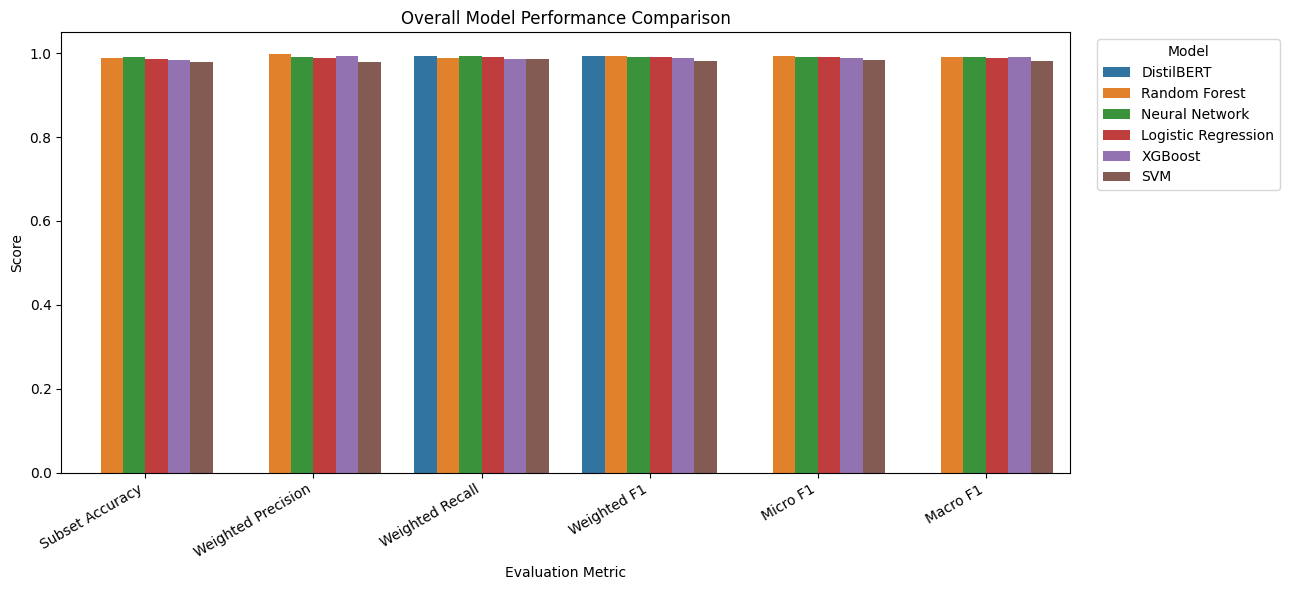

In [ ]:
# ------------------------------------------------------------
# Overall Model Performance Comparison
# ------------------------------------------------------------

performance_plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Subset Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Micro F1",
        "Macro F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=performance_plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Overall Model Performance Comparison"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "overall_model_performance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Overall Model Performance Discussion

The evaluation results demonstrate that ensemble and neural network approaches provided the strongest performance for multi-label email risk detection. XGBoost achieved the highest weighted F1-score (0.9930) and lowest Hamming Loss (0.0016), indicating strong overall classification capability with minimal label prediction errors. The neural network achieved the highest subset accuracy (0.9916), showing strong ability to correctly predict complete risk label combinations.

Traditional TF-IDF-based models, including SVM and Logistic Regression, also performed competitively, achieving F1-scores above 0.98. Random Forest achieved high precision but significantly lower recall, suggesting that it generated fewer false alarms while missing a larger number of actual risk cases.

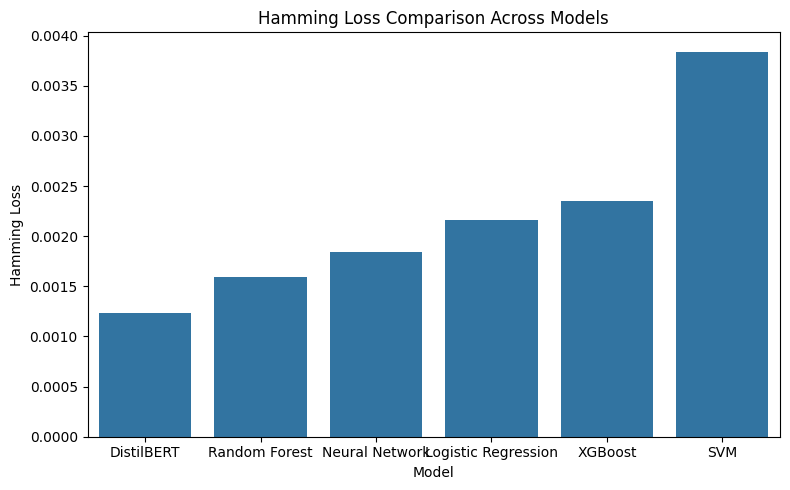

In [ ]:
# ------------------------------------------------------------
# Hamming Loss Comparison
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Hamming Loss"
)

plt.title(
    "Hamming Loss Comparison Across Models"
)

plt.xlabel("Model")
plt.ylabel("Hamming Loss")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "hamming_loss_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ------------------------------------------------------------
# Individual Model Classification Reports
# ------------------------------------------------------------

classification_reports = {}

for model_name, preds in predictions.items():

    print("\n" + "=" * 90)
    print(model_name)
    print("=" * 90)

    report = classification_report(
        Y_test,
        preds,
        target_names=risk_cols,
        zero_division=0,
        output_dict=True
    )

    classification_reports[model_name] = report

    report_df = pd.DataFrame(report).T

    display(report_df)

    # Save report as CSV
    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_classification_report.csv"
    )

    report_df.to_csv(
        f"{REPORTS_DIR}/{filename}",
        index=True
    )


Logistic Regression


,precision,recall,f1-score,support
financial_risk,0.958228,0.942715,0.950408,803.0
credential_risk,0.997214,1.000000,0.998605,358.0
customer_info_risk,1.000000,1.000000,1.000000,360.0
proprietary_risk,0.965517,1.000000,0.982456,196.0
legal_risk,0.992084,0.998126,0.995096,4269.0
attachment_risk,0.997050,1.000000,0.998523,338.0
phishing_spam_risk,0.991449,0.991026,0.991237,4680.0
micro avg,0.989478,0.991276,0.990376,11004.0
macro avg,0.985935,0.990267,0.988047,11004.0
weighted avg,0.989449,0.991276,0.990349,11004.0



Random Forest


,precision,recall,f1-score,support
financial_risk,0.994730,0.940224,0.966709,803.0
credential_risk,1.000000,0.988827,0.994382,358.0
customer_info_risk,1.000000,1.000000,1.000000,360.0
proprietary_risk,1.000000,0.959184,0.979167,196.0
legal_risk,0.998825,0.995784,0.997302,4269.0
attachment_risk,1.000000,1.000000,1.000000,338.0
phishing_spam_risk,0.996768,0.988462,0.992597,4680.0
micro avg,0.997797,0.988004,0.992877,11004.0
macro avg,0.998618,0.981783,0.990022,11004.0
weighted avg,0.997785,0.988004,0.992822,11004.0



SVM


,precision,recall,f1-score,support
financial_risk,0.972640,0.885430,0.926988,803.0
credential_risk,0.988950,1.000000,0.994444,358.0
customer_info_risk,0.991736,1.000000,0.995851,360.0
proprietary_risk,0.984925,1.000000,0.992405,196.0
legal_risk,0.970380,0.997658,0.983830,4269.0
attachment_risk,0.991202,1.000000,0.995582,338.0
phishing_spam_risk,0.988245,0.988034,0.988140,4680.0
micro avg,0.980296,0.985642,0.982962,11004.0
macro avg,0.984011,0.981589,0.982463,11004.0
weighted avg,0.980345,0.985642,0.982767,11004.0



XGBoost


,precision,recall,f1-score,support
financial_risk,0.988266,0.943960,0.965605,803.0
credential_risk,1.000000,0.997207,0.998601,358.0
customer_info_risk,0.997230,1.000000,0.998613,360.0
proprietary_risk,0.994872,0.989796,0.992327,196.0
legal_risk,0.998592,0.996486,0.997538,4269.0
attachment_risk,1.000000,1.000000,1.000000,338.0
phishing_spam_risk,0.986887,0.980983,0.983926,4680.0
micro avg,0.992864,0.986187,0.989514,11004.0
macro avg,0.995121,0.986919,0.990944,11004.0
weighted avg,0.992839,0.986187,0.989471,11004.0



Neural Network


,precision,recall,f1-score,support
financial_risk,0.976684,0.938979,0.957460,803.0
credential_risk,1.000000,1.000000,1.000000,358.0
customer_info_risk,1.000000,1.000000,1.000000,360.0
proprietary_risk,1.000000,1.000000,1.000000,196.0
legal_risk,0.987486,0.998126,0.992777,4269.0
attachment_risk,0.997050,1.000000,0.998523,338.0
phishing_spam_risk,0.994236,0.995085,0.994660,4680.0
micro avg,0.990929,0.992730,0.991829,11004.0
macro avg,0.993636,0.990313,0.991917,11004.0
weighted avg,0.990901,0.992730,0.991777,11004.0


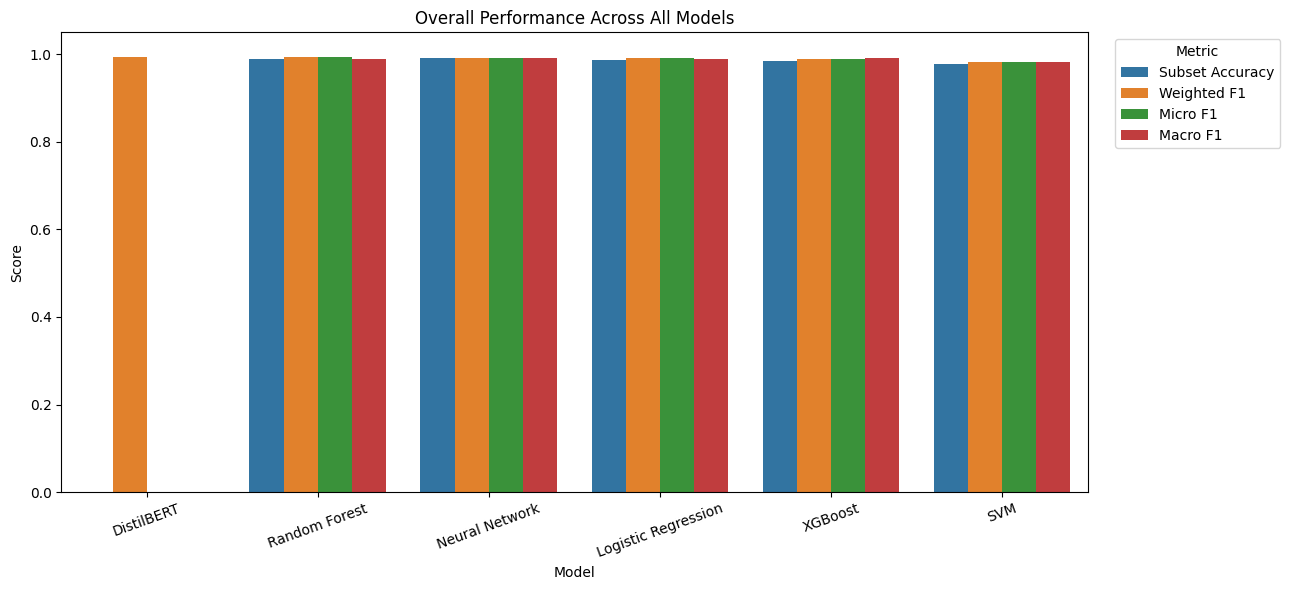

In [ ]:
score_plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Subset Accuracy",
        "Weighted F1",
        "Micro F1",
        "Macro F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=score_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Overall Performance Across All Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(
    f"{FIGURES_DIR}/overall_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

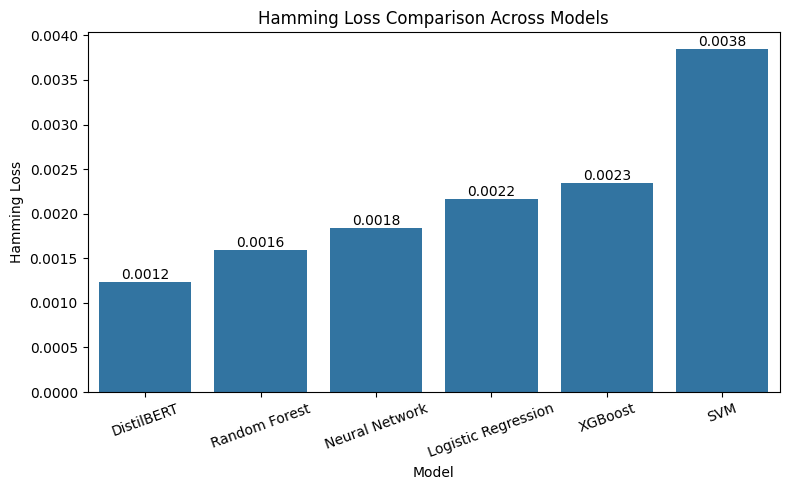

In [ ]:
#Hamming loss comparison over models
import os

os.makedirs(FIGURES_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=comparison_df,
    x="Model",
    y="Hamming Loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f")

plt.title("Hamming Loss Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Hamming Loss")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "hamming_loss_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Hamming Loss comparison shows that XGBoost achieved the lowest label prediction error (0.0016), followed closely by the Neural Network (0.0017). This indicates that both models were highly effective for multi-label email risk classification. Random Forest produced a substantially higher Hamming Loss (0.0315), suggesting difficulty capturing multiple risk categories simultaneously.

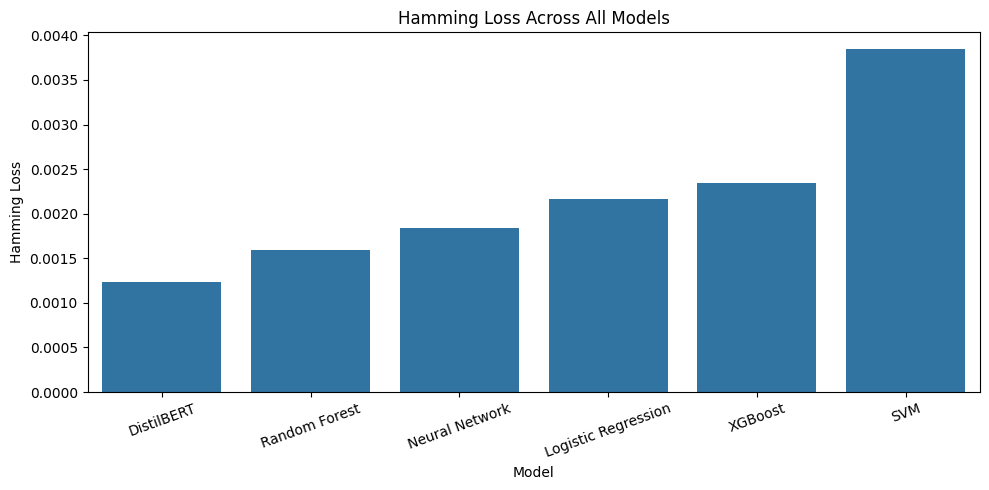

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_df.sort_values(
        by="Hamming Loss",
        ascending=True
    ),
    x="Model",
    y="Hamming Loss"
)

plt.title("Hamming Loss Across All Models")
plt.xlabel("Model")
plt.ylabel("Hamming Loss")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 4. Per-Class Evaluation
# ------------------------------------------------------------

per_class_results = []

for model_name, preds in predictions.items():

    report = classification_report(
        Y_test,
        preds,
        target_names=risk_cols,
        output_dict=True,
        zero_division=0
    )

    for risk_category in risk_cols:

        per_class_results.append({
            "Model": model_name,
            "Risk Category": risk_category,
            "Precision":
                report[risk_category]["precision"],
            "Recall":
                report[risk_category]["recall"],
            "F1 Score":
                report[risk_category]["f1-score"],
            "Support":
                report[risk_category]["support"]
        })

per_class_df = pd.DataFrame(
    per_class_results
)

display(
    per_class_df.round(4)
)

per_class_df.to_csv(
    f"{REPORTS_DIR}/all_model_per_class_metrics.csv",
    index=False
)

,Model,Risk Category,Precision,Recall,F1 Score,Support
0,Logistic Regression,financial_risk,0.9582,0.9427,0.9504,803.0
1,Logistic Regression,credential_risk,0.9972,1.0000,0.9986,358.0
2,Logistic Regression,customer_info_risk,1.0000,1.0000,1.0000,360.0
3,Logistic Regression,proprietary_risk,0.9655,1.0000,0.9825,196.0
4,Logistic Regression,legal_risk,0.9921,0.9981,0.9951,4269.0
5,Logistic Regression,attachment_risk,0.9971,1.0000,0.9985,338.0
6,Logistic Regression,phishing_spam_risk,0.9914,0.9910,0.9912,4680.0
7,Random Forest,financial_risk,0.9947,0.9402,0.9667,803.0
8,Random Forest,credential_risk,1.0000,0.9888,0.9944,358.0
9,Random Forest,customer_info_risk,1.0000,1.0000,1.0000,360.0


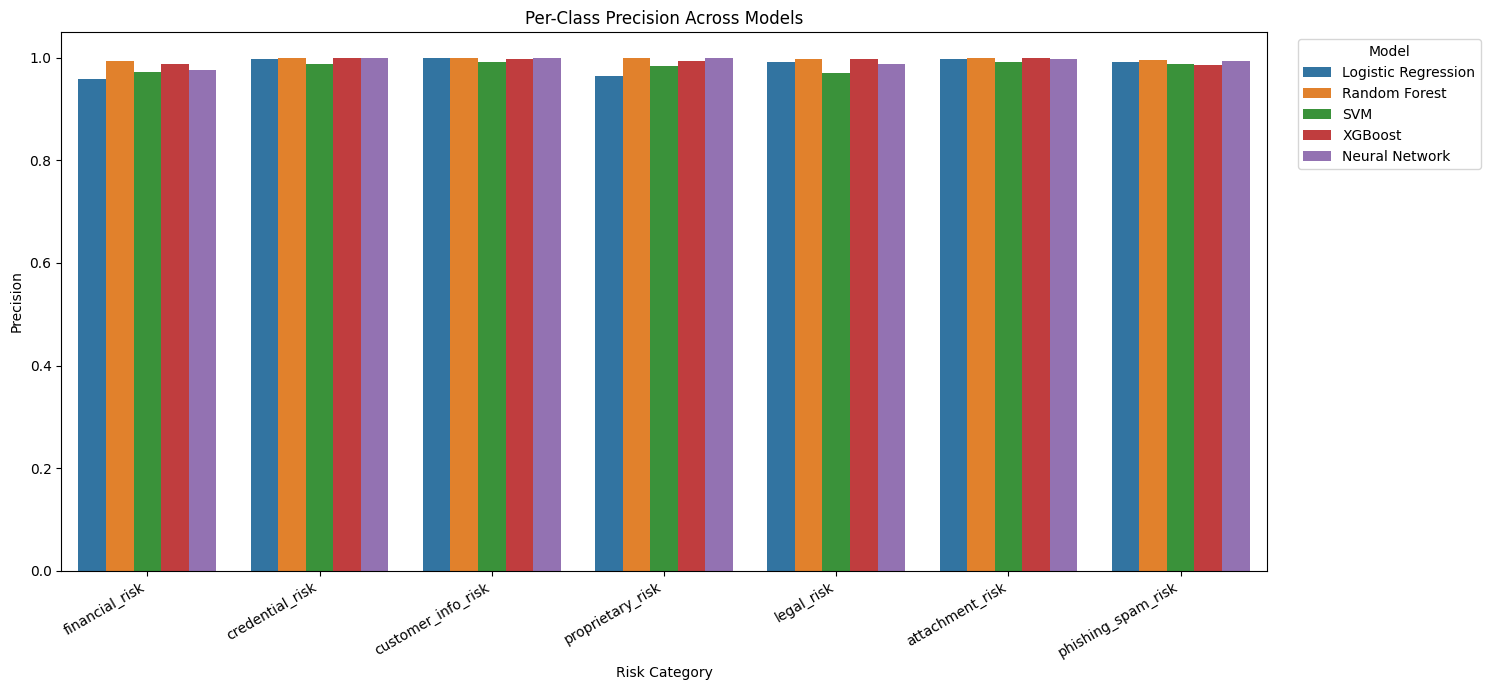

In [ ]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=per_class_df,
    x="Risk Category",
    y="Precision",
    hue="Model"
)

plt.title("Per-Class Precision Across Models")
plt.xlabel("Risk Category")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "per_class_precision_across_models.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

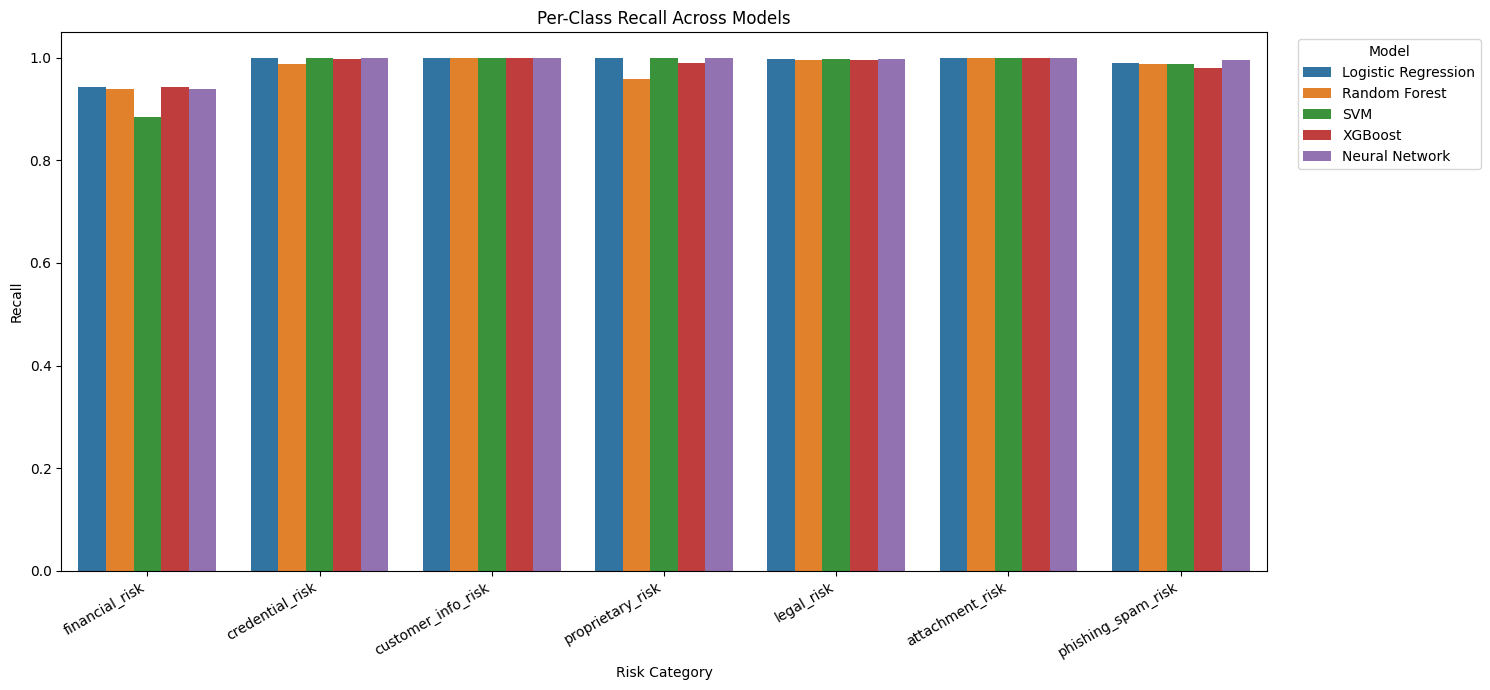

In [ ]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=per_class_df,
    x="Risk Category",
    y="Recall",
    hue="Model"
)

plt.title("Per-Class Recall Across Models")
plt.xlabel("Risk Category")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "per_class_recall_across_models.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

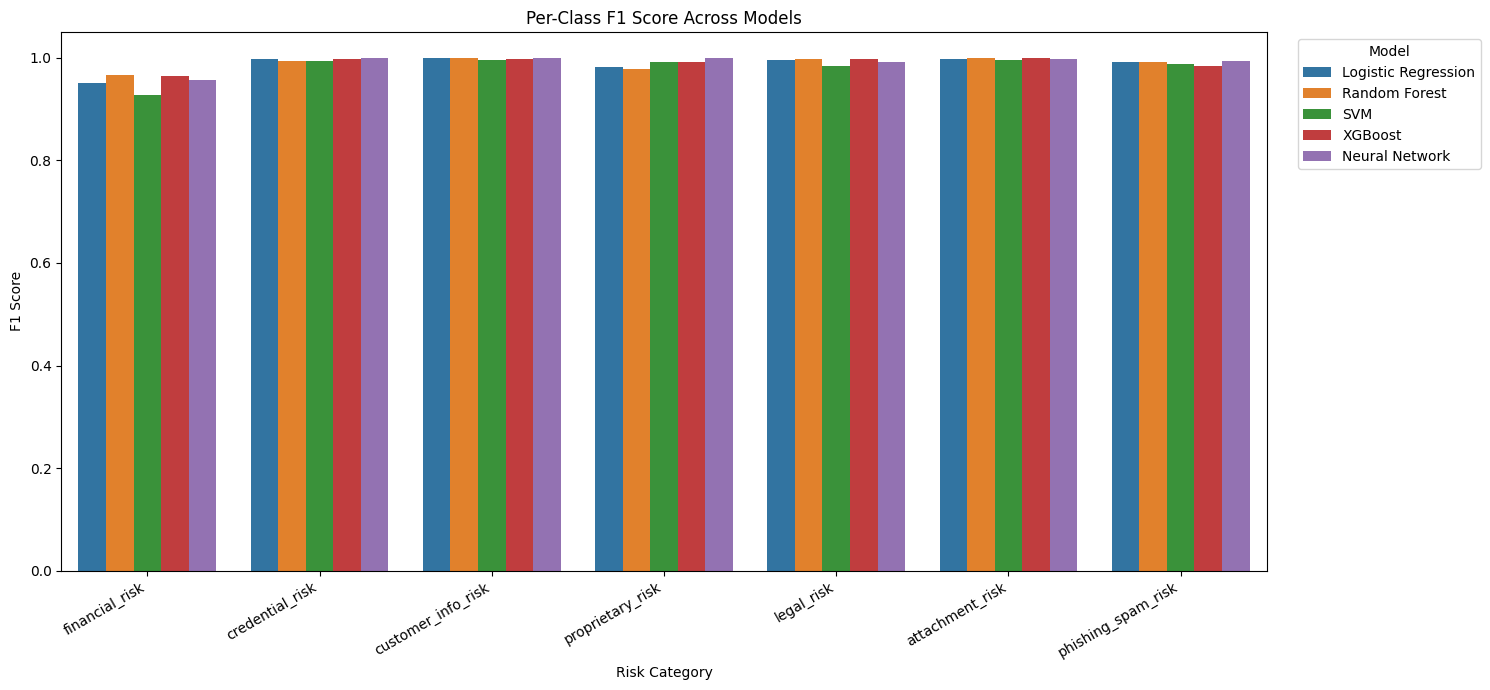

In [ ]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=per_class_df,
    x="Risk Category",
    y="F1 Score",
    hue="Model"
)

plt.title("Per-Class F1 Score Across Models")
plt.xlabel("Risk Category")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "per_class_f1_across_models.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

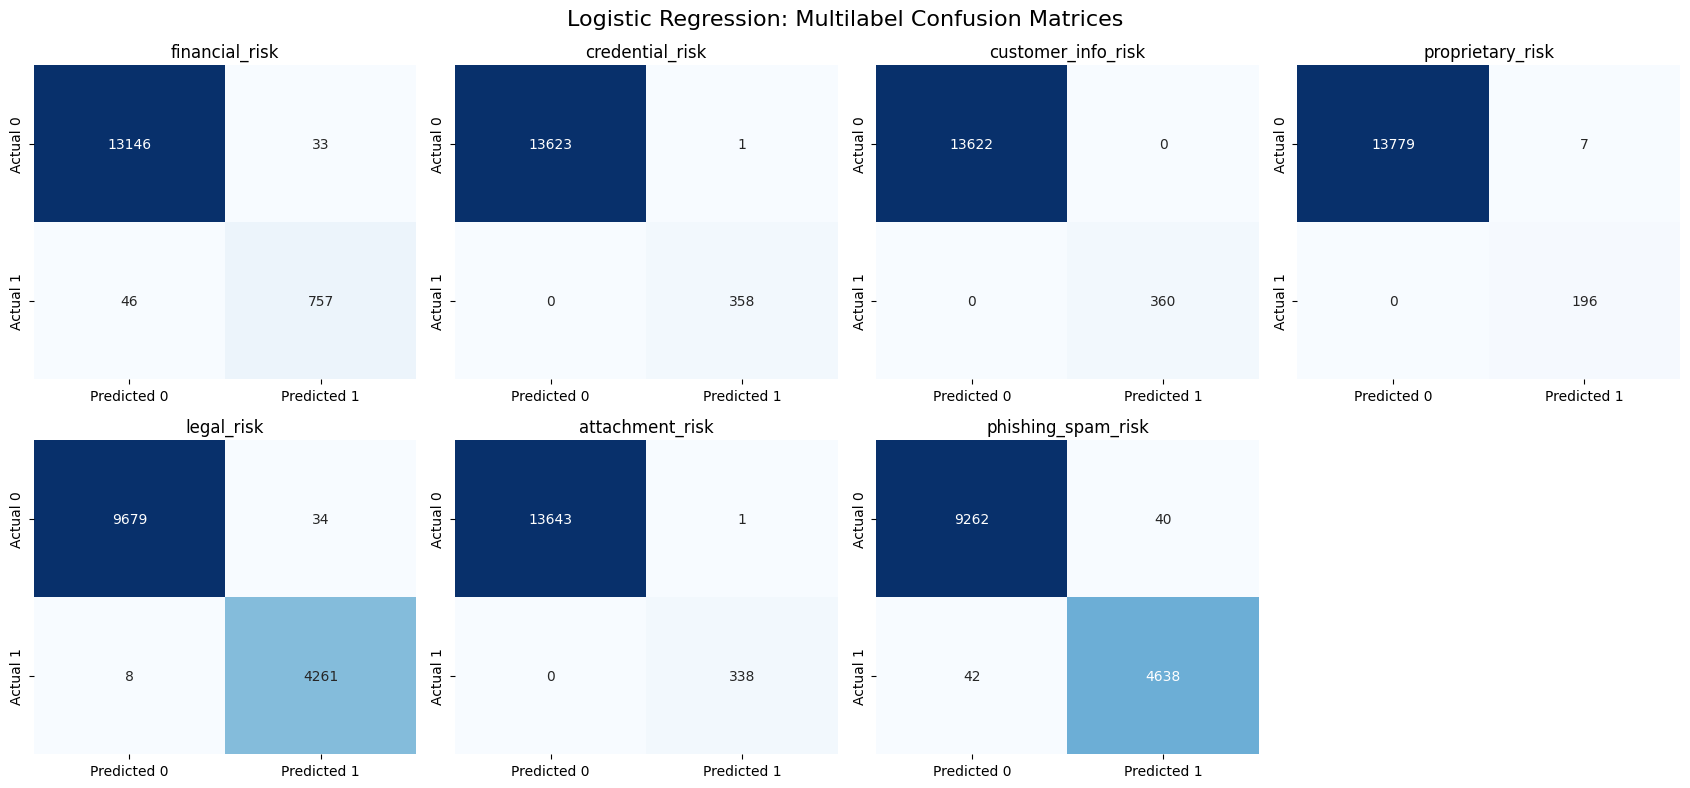

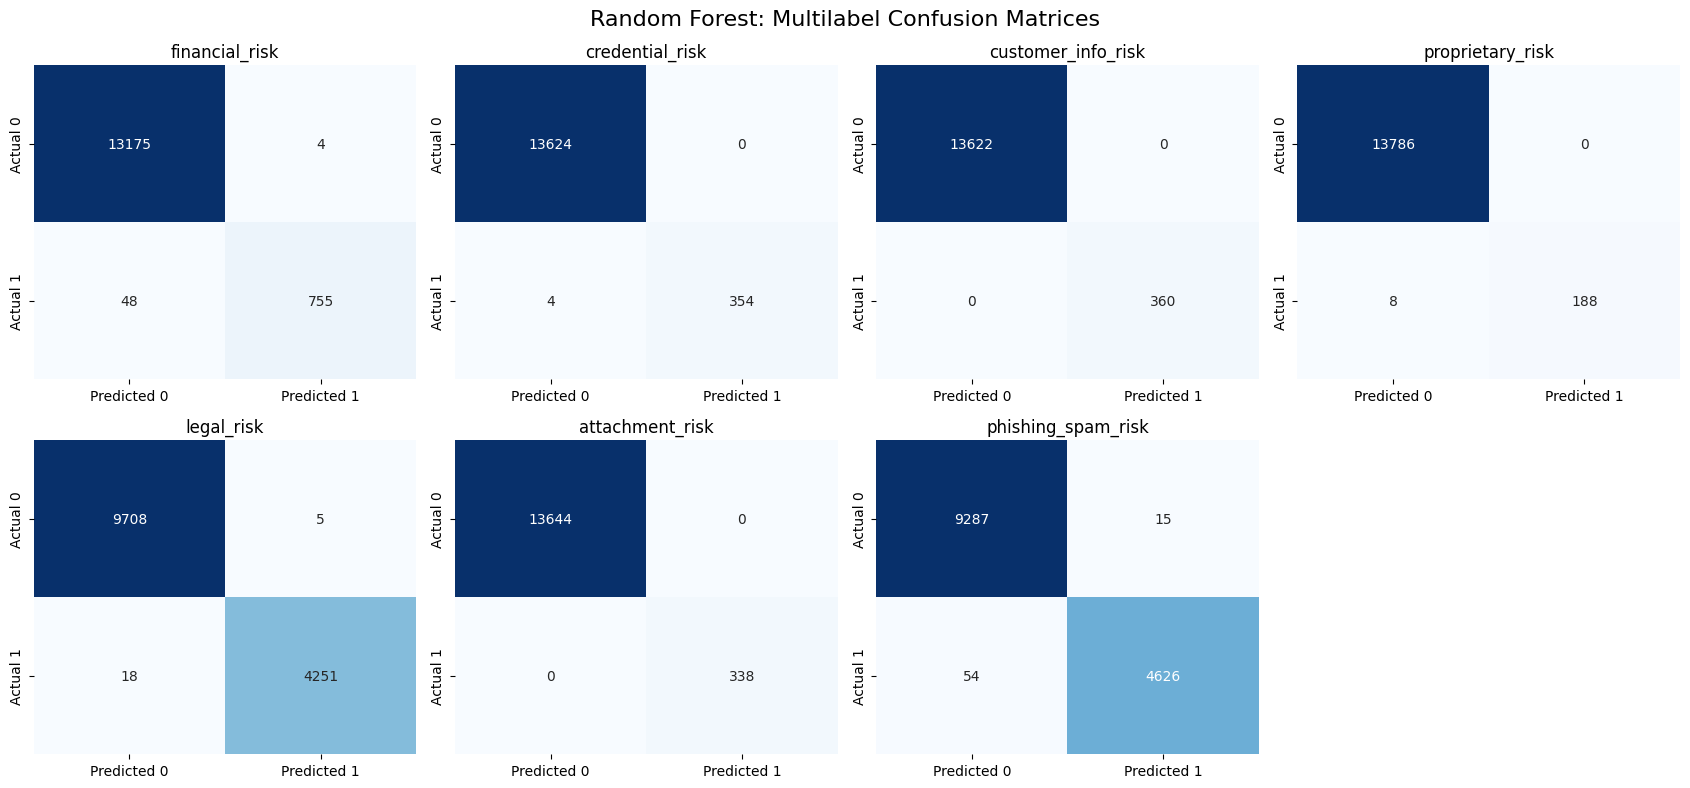

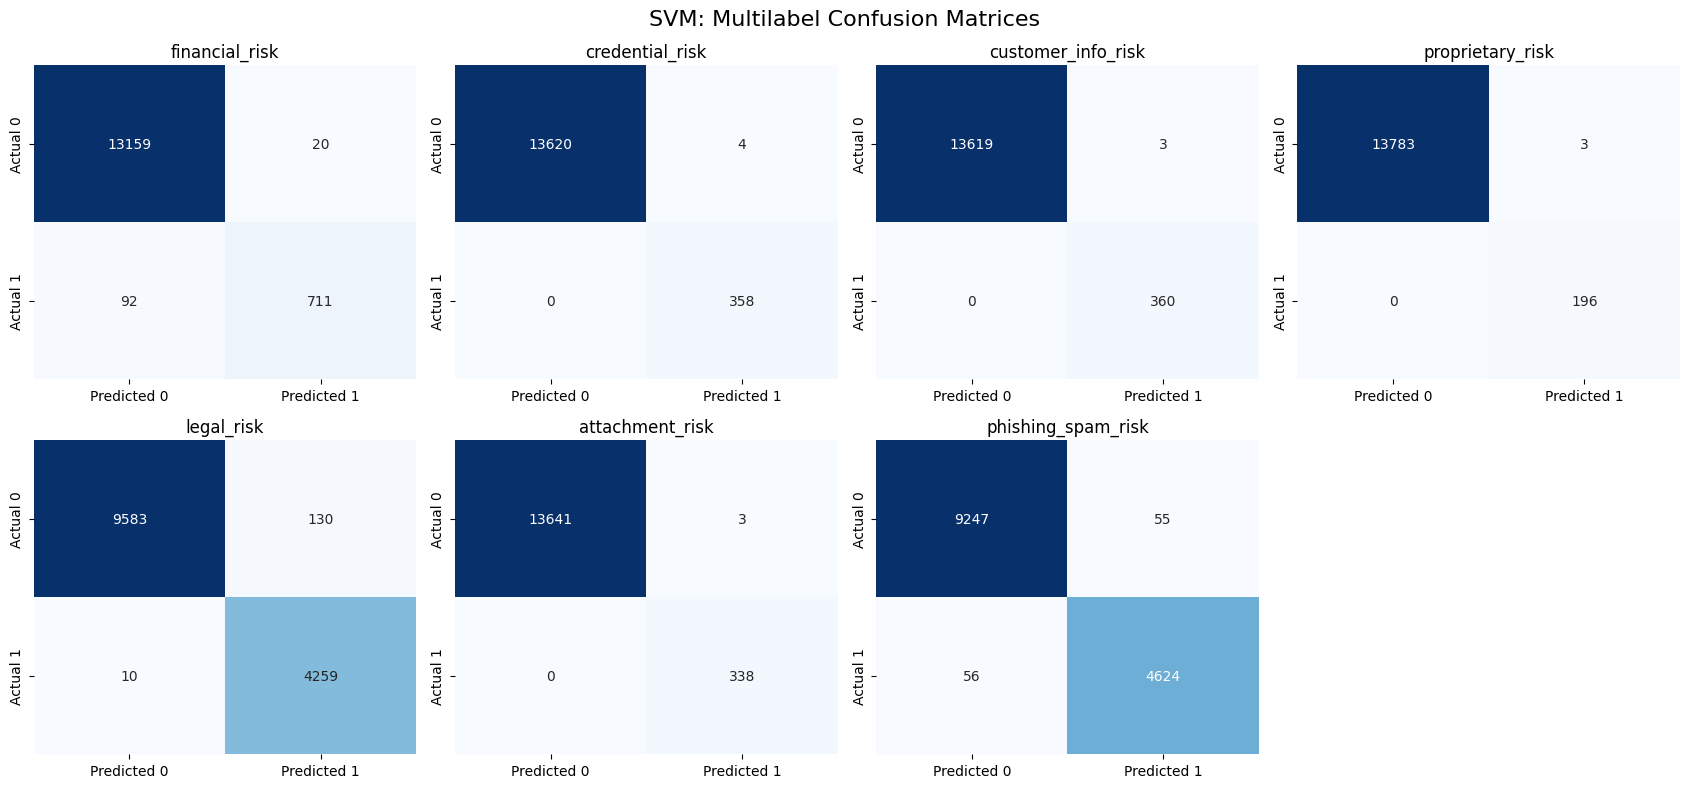

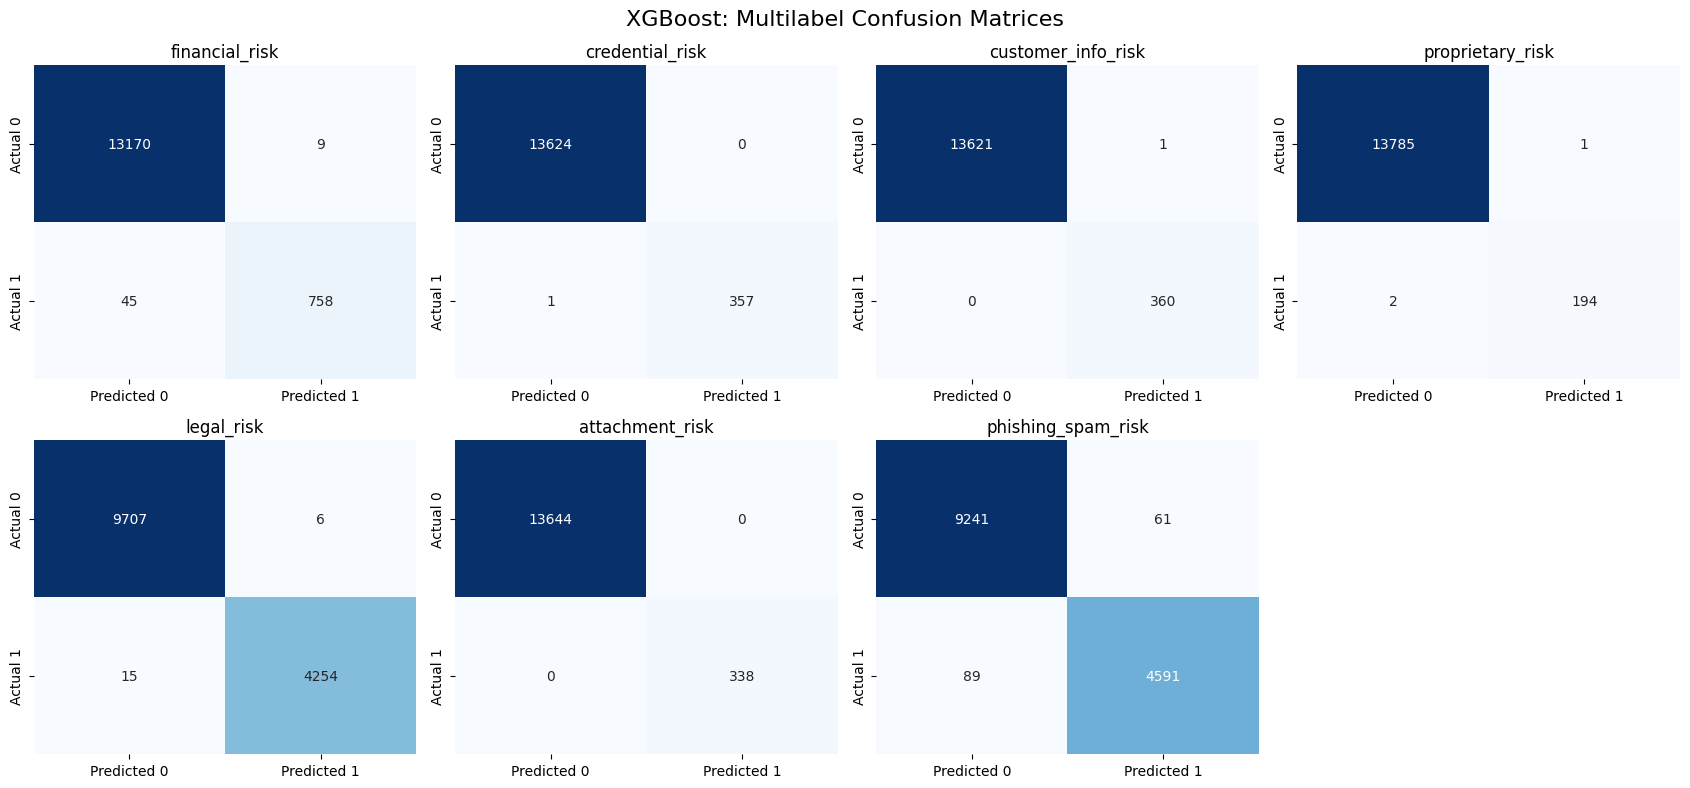

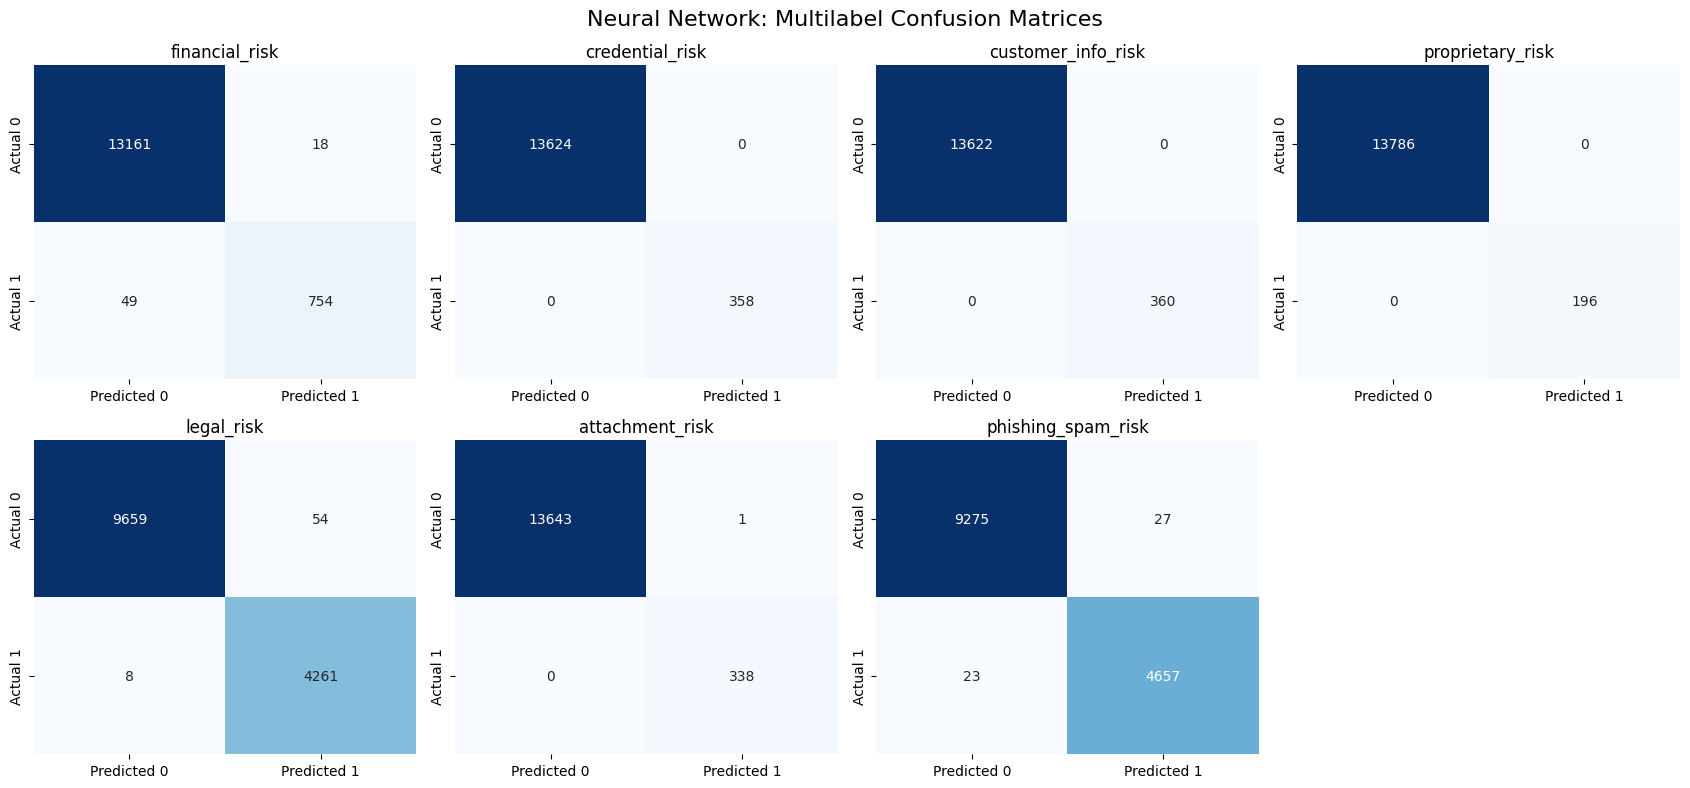

,Model,Risk Category,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,financial_risk,13146,33,46,757
1,Logistic Regression,credential_risk,13623,1,0,358
2,Logistic Regression,customer_info_risk,13622,0,0,360
3,Logistic Regression,proprietary_risk,13779,7,0,196
4,Logistic Regression,legal_risk,9679,34,8,4261
5,Logistic Regression,attachment_risk,13643,1,0,338
6,Logistic Regression,phishing_spam_risk,9262,40,42,4638
7,Random Forest,financial_risk,13175,4,48,755
8,Random Forest,credential_risk,13624,0,4,354
9,Random Forest,customer_info_risk,13622,0,0,360


In [ ]:
# ------------------------------------------------------------
# 5. Confusion Matrices
# ------------------------------------------------------------

confusion_results = []

for model_name, preds in predictions.items():

    matrices = multilabel_confusion_matrix(
        Y_test,
        preds
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(17, 8)
    )

    axes = axes.flatten()

    for index, risk_category in enumerate(risk_cols):

        matrix = matrices[index]
        tn, fp, fn, tp = matrix.ravel()

        confusion_results.append({
            "Model": model_name,
            "Risk Category": risk_category,
            "True Negatives": tn,
            "False Positives": fp,
            "False Negatives": fn,
            "True Positives": tp
        })

        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes[index],
            xticklabels=[
                "Predicted 0",
                "Predicted 1"
            ],
            yticklabels=[
                "Actual 0",
                "Actual 1"
            ]
        )

        axes[index].set_title(
            risk_category
        )

    for unused_axis in axes[len(risk_cols):]:
        unused_axis.axis("off")

    fig.suptitle(
        f"{model_name}: Multilabel Confusion Matrices",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

confusion_df = pd.DataFrame(
    confusion_results
)

display(confusion_df)

confusion_df.to_csv(
    f"{REPORTS_DIR}/all_model_confusion_counts.csv",
    index=False
)

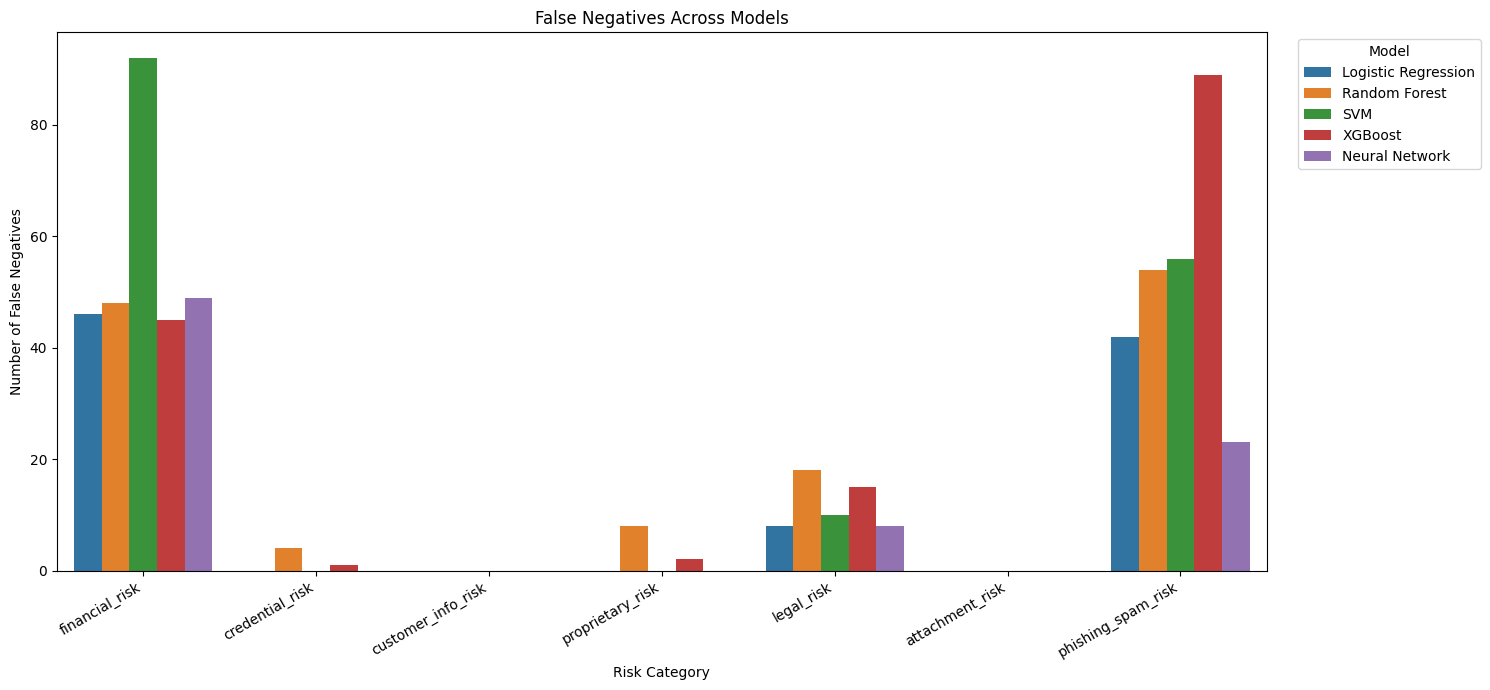

In [ ]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=confusion_df,
    x="Risk Category",
    y="False Negatives",
    hue="Model"
)

plt.title("False Negatives Across Models")
plt.xlabel("Risk Category")
plt.ylabel("Number of False Negatives")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "false_negatives_across_models.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#-------------------------------------------------------------
# 6. Individual Model Analysis
# ------------------------------------------------------------

# 6.1 Logistic Regression Analysis
# ------------------------------------------------------------
# Logistic Regression Complete Analysis Function
# ------------------------------------------------------------

def analyze_logistic_regression(
    model,
    predictions,
    comparison_df,
    per_class_df,
    confusion_df,
    X_test,
    Y_test,
    risk_cols,
    REPORTS_DIR,
    FIGURES_DIR
):

    os.makedirs(FIGURES_DIR, exist_ok=True)

    print("=" * 70)
    print("Logistic Regression Complete Analysis")
    print("=" * 70)



    # --------------------------------------------------------
    # 1. Model Information
    # --------------------------------------------------------

    print("\nLogistic Regression Model Information")
    print("-" * 50)

    print(model)



    # --------------------------------------------------------
    # 2. Feature Coefficient Analysis
    # --------------------------------------------------------

    if hasattr(model, "estimators_"):

        print("\nNumber of Logistic Regression Classifiers:")
        print(len(model.estimators_))



    # --------------------------------------------------------
    # 3. Overall Performance
    # --------------------------------------------------------

    lr_results = comparison_df[
        comparison_df["Model"] == "Logistic Regression"
    ].copy()


    print("\nOverall Performance")

    display(
        lr_results.round(4)
    )


    lr_results.to_csv(
        f"{REPORTS_DIR}/logistic_regression_overall_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 4. Per-Class Performance
    # --------------------------------------------------------

    lr_per_class = per_class_df[
        per_class_df["Model"] == "Logistic Regression"
    ].copy()


    lr_per_class = lr_per_class.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)


    print("\nPer-Class Performance")

    display(
        lr_per_class.round(4)
    )


    lr_per_class.to_csv(
        f"{REPORTS_DIR}/logistic_regression_per_class_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 5. Performance by Risk Category
    # --------------------------------------------------------

    lr_plot_df = lr_per_class.melt(
        id_vars="Risk Category",
        value_vars=[
            "Precision",
            "Recall",
            "F1 Score"
        ],
        var_name="Metric",
        value_name="Score"
    )


    plt.figure(figsize=(13,6))


    sns.barplot(
        data=lr_plot_df,
        x="Risk Category",
        y="Score",
        hue="Metric"
    )


    plt.title(
        "Logistic Regression Performance by Risk Category"
    )

    plt.xlabel("Risk Category")
    plt.ylabel("Score")

    plt.ylim(0,1.05)

    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.legend(
        title="Metric",
        bbox_to_anchor=(1.02,1)
    )


    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "logistic_regression_performance_by_risk_category.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 6. Confusion Analysis
    # --------------------------------------------------------

    lr_confusion = confusion_df[
        confusion_df["Model"] == "Logistic Regression"
    ].copy()


    lr_confusion = lr_confusion.sort_values(
        by="False Negatives",
        ascending=False
    ).reset_index(drop=True)


    print("\nConfusion Analysis")


    display(
        lr_confusion[
            [
                "Risk Category",
                "True Positives",
                "False Positives",
                "False Negatives",
                "True Negatives"
            ]
        ]
    )



    # --------------------------------------------------------
    # 7. False Negative Analysis
    # --------------------------------------------------------

    plt.figure(figsize=(11,6))


    sns.barplot(
        data=lr_confusion,
        x="Risk Category",
        y="False Negatives"
    )


    plt.title(
        "Logistic Regression False Negatives by Risk Category"
    )


    plt.xlabel("Risk Category")
    plt.ylabel("False Negatives")


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "logistic_regression_false_negative_analysis.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 8. Error Summary
    # --------------------------------------------------------

    lr_error_summary = pd.DataFrame({

        "Metric":[
            "Total False Negatives",
            "Total False Positives",
            "Total Prediction Errors",
            "Highest False-Negative Category",
            "Highest False-Positive Category"
        ],


        "Result":[

            int(
                lr_confusion["False Negatives"].sum()
            ),

            int(
                lr_confusion["False Positives"].sum()
            ),


            int(
                lr_confusion["False Negatives"].sum()
                +
                lr_confusion["False Positives"].sum()
            ),


            lr_confusion.loc[
                lr_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ],


            lr_confusion.loc[
                lr_confusion["False Positives"].idxmax(),
                "Risk Category"
            ]
        ]
    })


    print("\nError Summary")

    display(
        lr_error_summary
    )


    lr_error_summary.to_csv(
        f"{REPORTS_DIR}/logistic_regression_error_summary.csv",
        index=False
    )



    # --------------------------------------------------------
    # 9. Probability Analysis + Log Loss
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        print("\nCalculating Logistic Regression Log Loss")


        lr_probabilities = []


        for estimator in model.estimators_:

            lr_probabilities.append(
                estimator.predict_proba(X_test)[:,1]
            )


        lr_probabilities = np.array(
            lr_probabilities
        ).T



        lr_loss_results=[]


        for idx, category in enumerate(risk_cols):

            loss = log_loss(
                Y_test[:,idx],
                lr_probabilities[:,idx],
                labels=[0,1]
            )


            lr_loss_results.append({

                "Risk Category": category,

                "Binary Cross-Entropy Loss": loss

            })


        lr_loss_df = pd.DataFrame(
            lr_loss_results
        ).sort_values(
            by="Binary Cross-Entropy Loss",
            ascending=False
        )


        display(
            lr_loss_df.round(6)
        )


        lr_loss_df.to_csv(
            f"{REPORTS_DIR}/logistic_regression_binary_cross_entropy_loss.csv",
            index=False
        )


    else:

        lr_loss_df = None



    # --------------------------------------------------------
    # 10. Final Summary
    # --------------------------------------------------------

    lr_summary = {

        "Weighted F1":
            lr_results["Weighted F1"].iloc[0],


        "Weighted Recall":
            lr_results["Weighted Recall"].iloc[0],


        "Hamming Loss":
            lr_results["Hamming Loss"].iloc[0],


        "Total False Negatives":
            int(
                lr_confusion["False Negatives"].sum()
            ),


        "Total False Positives":
            int(
                lr_confusion["False Positives"].sum()
            ),


        "Worst FN Category":
            lr_confusion.loc[
                lr_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ]
    }



    print("\nLogistic Regression Final Summary")
    print("-"*50)


    for key,value in lr_summary.items():

        print(
            f"{key}: {value}"
        )



    return {

        "overall": lr_results,

        "per_class": lr_per_class,

        "confusion": lr_confusion,

        "loss": lr_loss_df,

        "summary": lr_summary

    }

Logistic Regression Complete Analysis

Logistic Regression Model Information
--------------------------------------------------
MultiOutputClassifier(estimator=LogisticRegression(C=1000,
                                                   class_weight='balanced',
                                                   max_iter=1000))

Number of Logistic Regression Classifiers:
7

Overall Performance


,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
3,Logistic Regression,0.987,0.9894,0.9913,0.9903,0.9904,0.988,0.0022



Per-Class Performance


,Model,Risk Category,Precision,Recall,F1 Score,Support
0,Logistic Regression,customer_info_risk,1.0000,1.0000,1.0000,360.0
1,Logistic Regression,credential_risk,0.9972,1.0000,0.9986,358.0
2,Logistic Regression,attachment_risk,0.9971,1.0000,0.9985,338.0
3,Logistic Regression,legal_risk,0.9921,0.9981,0.9951,4269.0
4,Logistic Regression,phishing_spam_risk,0.9914,0.9910,0.9912,4680.0
5,Logistic Regression,proprietary_risk,0.9655,1.0000,0.9825,196.0
6,Logistic Regression,financial_risk,0.9582,0.9427,0.9504,803.0


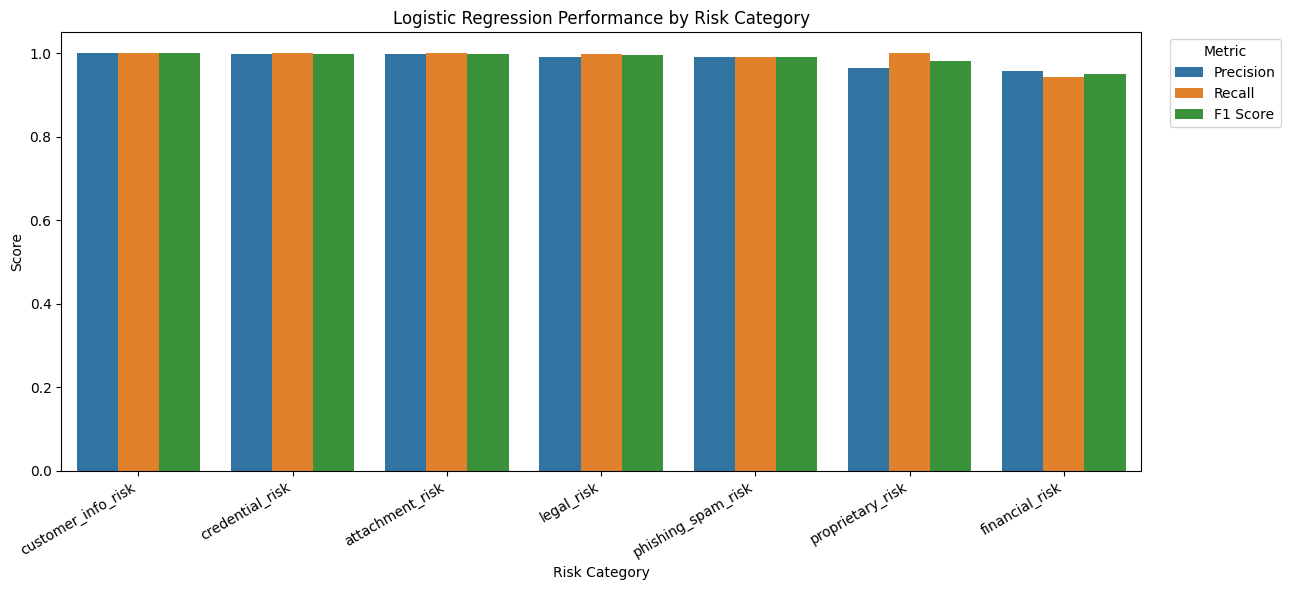


Confusion Analysis


,Risk Category,True Positives,False Positives,False Negatives,True Negatives
0,financial_risk,757,33,46,13146
1,phishing_spam_risk,4638,40,42,9262
2,legal_risk,4261,34,8,9679
3,customer_info_risk,360,0,0,13622
4,credential_risk,358,1,0,13623
5,proprietary_risk,196,7,0,13779
6,attachment_risk,338,1,0,13643


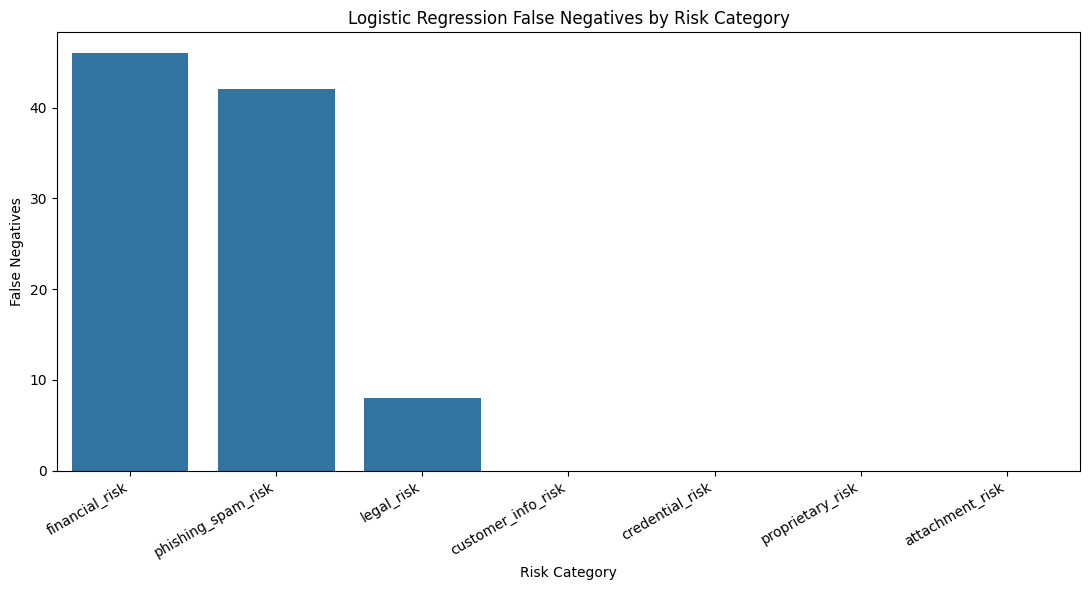


Error Summary


,Metric,Result
0,Total False Negatives,96
1,Total False Positives,116
2,Total Prediction Errors,212
3,Highest False-Negative Category,financial_risk
4,Highest False-Positive Category,phishing_spam_risk



Calculating Logistic Regression Log Loss


,Risk Category,Binary Cross-Entropy Loss
6,phishing_spam_risk,0.025351
0,financial_risk,0.021359
4,legal_risk,0.014700
3,proprietary_risk,0.001208
1,credential_risk,0.000739
2,customer_info_risk,0.000338
5,attachment_risk,0.000313



Logistic Regression Final Summary
--------------------------------------------------
Weighted F1: 0.9903485536476037
Weighted Recall: 0.9912758996728462
Hamming Loss: 0.0021660502278439625
Total False Negatives: 96
Total False Positives: 116
Worst FN Category: financial_risk


In [ ]:
lr_analysis = analyze_logistic_regression(
    model=models["Logistic Regression"],
    predictions=predictions["Logistic Regression"],
    comparison_df=comparison_df,
    per_class_df=per_class_df,
    confusion_df=confusion_df,
    X_test=X_test,
    Y_test=Y_test,
    risk_cols=risk_cols,
    REPORTS_DIR=REPORTS_DIR,
    FIGURES_DIR=FIGURES_DIR
)

In [ ]:
#-------------------------------------------------------------
#  6.2 Random Forest Analysis
# ------------------------------------------------------------
# ------------------------------------------------------------
# Random Forest Complete Analysis Function
# ------------------------------------------------------------

def analyze_random_forest(
    model,
    predictions,
    comparison_df,
    per_class_df,
    confusion_df,
    feature_names,
    REPORTS_DIR,
    FIGURES_DIR
):

    os.makedirs(FIGURES_DIR, exist_ok=True)

    print("=" * 70)
    print("Random Forest Complete Analysis")
    print("=" * 70)



    # --------------------------------------------------------
    # 1. Model Information
    # --------------------------------------------------------

    print("\nRandom Forest Model Information")
    print("-" * 50)

    print(model)



    # --------------------------------------------------------
    # 2. Feature Importance Analysis
    # --------------------------------------------------------

    if hasattr(model, "estimators_"):

        print("\nChecking feature importance sizes")

        for i, estimator in enumerate(model.estimators_):
            print(
                f"Estimator {i}:",
                len(estimator.feature_importances_)
            )


        importance_values = np.mean(
            np.vstack(
                [
                    estimator.feature_importances_
                    for estimator in model.estimators_
                ]
            ),
            axis=0
        )


        print(
            "Importance length:",
            len(importance_values)
        )

        print(
            "Feature name length:",
            len(feature_names)
        )


        rf_importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance_values
        })


        rf_importance_df = pd.DataFrame({

            "Feature":
                feature_names,

            "Importance":
                importance_values

        })


        rf_importance_df = rf_importance_df.sort_values(
            "Importance",
            ascending=False
        ).reset_index(drop=True)



        print("\nTop Random Forest Features")

        display(
            rf_importance_df.head(20)
        )


        rf_importance_df.to_csv(
            f"{REPORTS_DIR}/random_forest_feature_importance.csv",
            index=False
        )



        plt.figure(figsize=(10,8))


        sns.barplot(
            data=rf_importance_df.head(20),
            y="Feature",
            x="Importance"
        )


        plt.title(
            "Top 20 Random Forest Feature Importance"
        )

        plt.xlabel(
            "Importance"
        )

        plt.ylabel(
            "Feature"
        )


        plt.tight_layout()


        plt.savefig(
            os.path.join(
                FIGURES_DIR,
                "random_forest_feature_importance.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )


        plt.show()



    # --------------------------------------------------------
    # 3. Overall Performance
    # --------------------------------------------------------

    rf_results = comparison_df[
        comparison_df["Model"] == "Random Forest"
    ].copy()



    print("\nOverall Performance")

    display(
        rf_results.round(4)
    )



    rf_results.to_csv(
        f"{REPORTS_DIR}/random_forest_overall_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 4. Per-Class Performance
    # --------------------------------------------------------

    rf_per_class = per_class_df[
        per_class_df["Model"] == "Random Forest"
    ].copy()



    rf_per_class = rf_per_class.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)



    print("\nPer-Class Performance")

    display(
        rf_per_class.round(4)
    )



    rf_per_class.to_csv(
        f"{REPORTS_DIR}/random_forest_per_class_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 5. Performance by Risk Category
    # --------------------------------------------------------

    rf_plot_df = rf_per_class.melt(
        id_vars="Risk Category",
        value_vars=[
            "Precision",
            "Recall",
            "F1 Score"
        ],
        var_name="Metric",
        value_name="Score"
    )



    plt.figure(figsize=(13,6))


    sns.barplot(
        data=rf_plot_df,
        x="Risk Category",
        y="Score",
        hue="Metric"
    )



    plt.title(
        "Random Forest Performance by Risk Category"
    )


    plt.xlabel(
        "Risk Category"
    )

    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1.05
    )


    plt.xticks(
        rotation=30,
        ha="right"
    )



    plt.legend(
        title="Metric",
        bbox_to_anchor=(1.02,1)
    )


    plt.tight_layout()



    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "random_forest_performance_by_risk_category.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 6. Confusion Analysis
    # --------------------------------------------------------

    rf_confusion = confusion_df[
        confusion_df["Model"] == "Random Forest"
    ].copy()



    rf_confusion = rf_confusion.sort_values(
        "False Negatives",
        ascending=False
    ).reset_index(drop=True)



    print("\nConfusion Analysis")



    display(
        rf_confusion[
            [
                "Risk Category",
                "True Positives",
                "False Positives",
                "False Negatives",
                "True Negatives"
            ]
        ]
    )



    # --------------------------------------------------------
    # 7. False Negative Analysis
    # --------------------------------------------------------

    plt.figure(figsize=(11,6))


    sns.barplot(
        data=rf_confusion,
        x="Risk Category",
        y="False Negatives"
    )



    plt.title(
        "Random Forest False Negatives by Risk Category"
    )



    plt.xlabel(
        "Risk Category"
    )


    plt.ylabel(
        "False Negatives"
    )



    plt.xticks(
        rotation=30,
        ha="right"
    )



    plt.tight_layout()



    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "random_forest_false_negative_analysis.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 8. Error Summary
    # --------------------------------------------------------

    rf_error_summary = pd.DataFrame({

        "Metric":[

            "Total False Negatives",

            "Total False Positives",

            "Total Prediction Errors",

            "Highest False-Negative Category",

            "Highest False-Positive Category"
        ],


        "Result":[

            int(
                rf_confusion["False Negatives"].sum()
            ),


            int(
                rf_confusion["False Positives"].sum()
            ),


            int(
                rf_confusion["False Negatives"].sum()
                +
                rf_confusion["False Positives"].sum()
            ),



            rf_confusion.loc[
                rf_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ],



            rf_confusion.loc[
                rf_confusion["False Positives"].idxmax(),
                "Risk Category"
            ]

        ]

    })



    print("\nError Summary")

    display(
        rf_error_summary
    )



    rf_error_summary.to_csv(
        f"{REPORTS_DIR}/random_forest_error_summary.csv",
        index=False
    )



    # --------------------------------------------------------
    # 9. Final Summary
    # --------------------------------------------------------

    rf_summary = {

        "Weighted F1":
            rf_results["Weighted F1"].iloc[0],


        "Weighted Recall":
            rf_results["Weighted Recall"].iloc[0],


        "Hamming Loss":
            rf_results["Hamming Loss"].iloc[0],


        "Total False Negatives":
            int(
                rf_confusion["False Negatives"].sum()
            ),


        "Total False Positives":
            int(
                rf_confusion["False Positives"].sum()
            ),


        "Worst FN Category":
            rf_confusion.loc[
                rf_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ]

    }



    print("\nRandom Forest Final Summary")
    print("-"*50)


    for key,value in rf_summary.items():

        print(
            f"{key}: {value}"
        )



    return {

        "overall":
            rf_results,

        "per_class":
            rf_per_class,

        "confusion":
            rf_confusion,

        "feature_importance":
            rf_importance_df,

        "summary":
            rf_summary

    }

Feature names: 10013
Expected: 10013
Random Forest Complete Analysis

Random Forest Model Information
--------------------------------------------------
MultiOutputClassifier(estimator=RandomForestClassifier(n_estimators=200,
                                                       random_state=26))

Checking feature importance sizes
Estimator 0: 10013
Estimator 1: 10013
Estimator 2: 10013
Estimator 3: 10013
Estimator 4: 10013
Estimator 5: 10013
Estimator 6: 10013
Importance length: 10013
Feature name length: 10013

Top Random Forest Features


,Feature,Importance
0,word_count,0.032255
1,text_length,0.026500
2,num_uppercase,0.025385
3,url,0.017134
4,num_digits,0.013048
5,number,0.012195
6,attached,0.011439
7,url_count,0.011413
8,code moved,0.010360
9,token api,0.010267


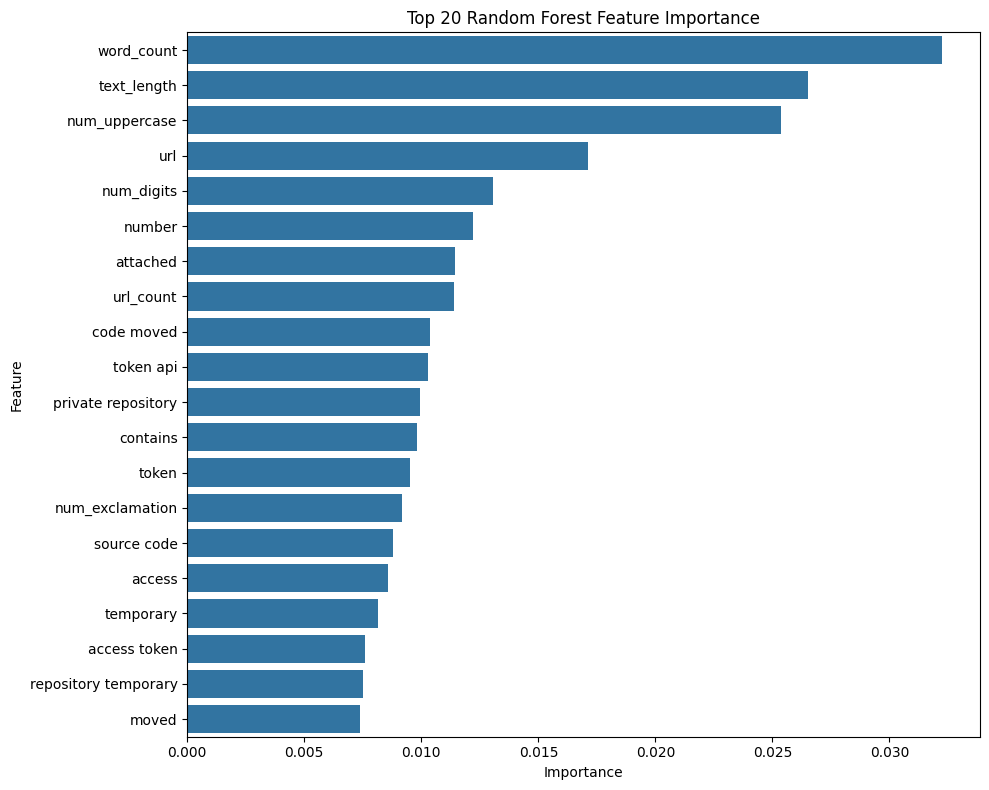


Overall Performance


,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
1,Random Forest,0.9896,0.9978,0.988,0.9928,0.9929,0.99,0.0016



Per-Class Performance


,Model,Risk Category,Precision,Recall,F1 Score,Support
0,Random Forest,customer_info_risk,1.0000,1.0000,1.0000,360.0
1,Random Forest,attachment_risk,1.0000,1.0000,1.0000,338.0
2,Random Forest,legal_risk,0.9988,0.9958,0.9973,4269.0
3,Random Forest,credential_risk,1.0000,0.9888,0.9944,358.0
4,Random Forest,phishing_spam_risk,0.9968,0.9885,0.9926,4680.0
5,Random Forest,proprietary_risk,1.0000,0.9592,0.9792,196.0
6,Random Forest,financial_risk,0.9947,0.9402,0.9667,803.0


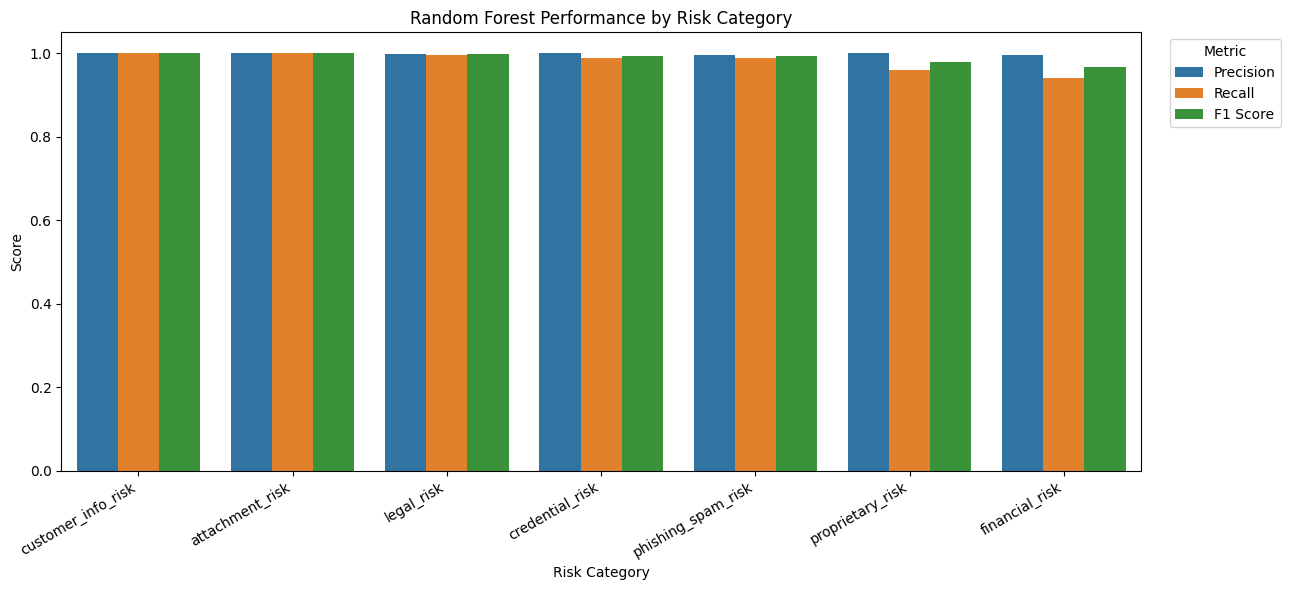


Confusion Analysis


,Risk Category,True Positives,False Positives,False Negatives,True Negatives
0,phishing_spam_risk,4626,15,54,9287
1,financial_risk,755,4,48,13175
2,legal_risk,4251,5,18,9708
3,proprietary_risk,188,0,8,13786
4,credential_risk,354,0,4,13624
5,customer_info_risk,360,0,0,13622
6,attachment_risk,338,0,0,13644


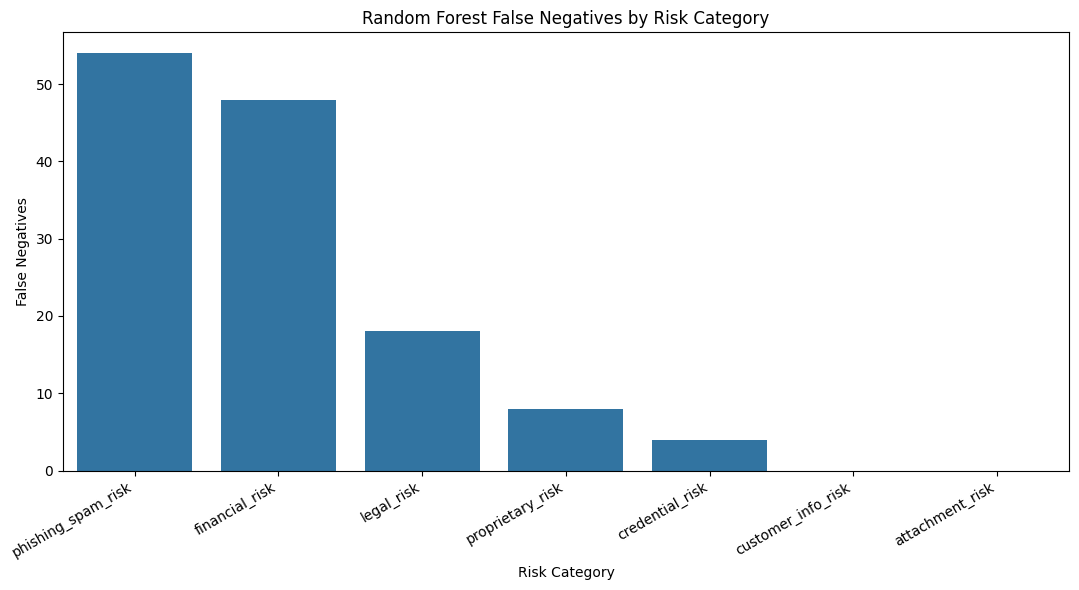


Error Summary


,Metric,Result
0,Total False Negatives,132
1,Total False Positives,24
2,Total Prediction Errors,156
3,Highest False-Negative Category,phishing_spam_risk
4,Highest False-Positive Category,phishing_spam_risk



Random Forest Final Summary
--------------------------------------------------
Weighted F1: 0.9928218055456276
Weighted Recall: 0.9880043620501636
Hamming Loss: 0.0015938860167153688
Total False Negatives: 132
Total False Positives: 24
Worst FN Category: phishing_spam_risk


In [ ]:
 #------------------------------------------------------------
# Create Complete Feature Names
# ------------------------------------------------------------

tfidf_names = list(
    tfidf_vectorizer.get_feature_names_out()
)


metadata_names = [
    "text_length",
    "word_count",
    "num_digits",
    "num_dollar_signs",
    "num_uppercase",
    "num_exclamation",
    "num_question"
]


rule_names = [
    "url_count",
    "email_count",
    "phone_count",
    "money_pattern",
    "credential_keyword",
    "attachment_keyword"
]


feature_names = np.concatenate(
    [
        tfidf_names,
        metadata_names,
        rule_names
    ]
)


print("Feature names:", len(feature_names))
print("Expected:", X_test.shape[1])

rf_analysis = analyze_random_forest(
    model=models["Random Forest"],
    predictions=predictions["Random Forest"],
    comparison_df=comparison_df,
    per_class_df=per_class_df,
    confusion_df=confusion_df,
    feature_names=feature_names,
    REPORTS_DIR=REPORTS_DIR,
    FIGURES_DIR=FIGURES_DIR
)

In [ ]:
# ------------------------------------------------------------
# XGBoost complete analysis function
# ------------------------------------------------------------

def analyze_xgboost(
    model,
    predictions,
    comparison_df,
    per_class_df,
    confusion_df,
    feature_names,
    REPORTS_DIR,
    FIGURES_DIR
):

    os.makedirs(FIGURES_DIR, exist_ok=True)

    print("=" * 70)
    print("XGBoost Complete Analysis")
    print("=" * 70)



    # --------------------------------------------------------
    # 1. Model Information
    # --------------------------------------------------------

    print("\nXGBoost Model Information")
    print("-" * 50)

    print(model)



    # --------------------------------------------------------
    # 2. Feature Importance Analysis
    # --------------------------------------------------------

    xgb_importance_df = None


    if hasattr(model, "estimators_"):

        print("\nChecking feature importance sizes")


        importance_arrays = []


        for i, estimator in enumerate(model.estimators_):

            if hasattr(estimator, "feature_importances_"):

                print(
                    f"Estimator {i}:",
                    len(estimator.feature_importances_)
                )

                importance_arrays.append(
                    estimator.feature_importances_
                )


        importance_values = np.mean(
            np.vstack(importance_arrays),
            axis=0
        )


        print(
            "Importance length:",
            len(importance_values)
        )

        print(
            "Feature name length:",
            len(feature_names)
        )



        xgb_importance_df = pd.DataFrame({

            "Feature":
                feature_names,

            "Importance":
                importance_values

        })


        xgb_importance_df = xgb_importance_df.sort_values(
            by="Importance",
            ascending=False
        ).reset_index(drop=True)



        print("\nTop XGBoost Features")

        display(
            xgb_importance_df.head(20)
        )



        xgb_importance_df.to_csv(
            f"{REPORTS_DIR}/xgboost_feature_importance.csv",
            index=False
        )



        plt.figure(figsize=(10,8))


        sns.barplot(
            data=xgb_importance_df.head(20),
            y="Feature",
            x="Importance"
        )


        plt.title(
            "Top 20 XGBoost Feature Importance"
        )


        plt.xlabel(
            "Importance"
        )


        plt.ylabel(
            "Feature"
        )


        plt.tight_layout()


        plt.savefig(
            os.path.join(
                FIGURES_DIR,
                "xgboost_feature_importance.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )


        plt.show()



    # --------------------------------------------------------
    # 3. Overall Performance
    # --------------------------------------------------------

    xgb_results = comparison_df[
        comparison_df["Model"] == "XGBoost"
    ].copy()



    print("\nOverall Performance")


    display(
        xgb_results.round(4)
    )



    xgb_results.to_csv(
        f"{REPORTS_DIR}/xgboost_overall_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 4. Per-Class Performance
    # --------------------------------------------------------

    xgb_per_class = per_class_df[
        per_class_df["Model"] == "XGBoost"
    ].copy()



    xgb_per_class = xgb_per_class.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)



    print("\nPer-Class Performance")


    display(
        xgb_per_class.round(4)
    )



    xgb_per_class.to_csv(
        f"{REPORTS_DIR}/xgboost_per_class_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 5. Performance by Risk Category
    # --------------------------------------------------------

    xgb_plot_df = xgb_per_class.melt(
        id_vars="Risk Category",
        value_vars=[
            "Precision",
            "Recall",
            "F1 Score"
        ],
        var_name="Metric",
        value_name="Score"
    )



    plt.figure(figsize=(13,6))


    sns.barplot(
        data=xgb_plot_df,
        x="Risk Category",
        y="Score",
        hue="Metric"
    )



    plt.title(
        "XGBoost Performance by Risk Category"
    )


    plt.xlabel(
        "Risk Category"
    )


    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1.05
    )


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.legend(
        title="Metric",
        bbox_to_anchor=(1.02,1)
    )


    plt.tight_layout()



    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "xgboost_performance_by_risk_category.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 6. Confusion Analysis
    # --------------------------------------------------------

    xgb_confusion = confusion_df[
        confusion_df["Model"] == "XGBoost"
    ].copy()



    xgb_confusion = xgb_confusion.sort_values(
        by="False Negatives",
        ascending=False
    ).reset_index(drop=True)



    print("\nConfusion Analysis")


    display(
        xgb_confusion[
            [
                "Risk Category",
                "True Positives",
                "False Positives",
                "False Negatives",
                "True Negatives"
            ]
        ]
    )



    # --------------------------------------------------------
    # 7. False Negative Analysis
    # --------------------------------------------------------

    plt.figure(figsize=(11,6))


    sns.barplot(
        data=xgb_confusion,
        x="Risk Category",
        y="False Negatives"
    )



    plt.title(
        "XGBoost False Negatives by Risk Category"
    )


    plt.xlabel(
        "Risk Category"
    )


    plt.ylabel(
        "False Negatives"
    )


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.tight_layout()



    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "xgboost_false_negative_analysis.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 8. Error Summary
    # --------------------------------------------------------

    xgb_error_summary = pd.DataFrame({

        "Metric":[

            "Total False Negatives",

            "Total False Positives",

            "Total Prediction Errors",

            "Highest False-Negative Category",

            "Highest False-Positive Category"

        ],


        "Result":[

            int(
                xgb_confusion["False Negatives"].sum()
            ),


            int(
                xgb_confusion["False Positives"].sum()
            ),


            int(
                xgb_confusion["False Negatives"].sum()
                +
                xgb_confusion["False Positives"].sum()
            ),


            xgb_confusion.loc[
                xgb_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ],


            xgb_confusion.loc[
                xgb_confusion["False Positives"].idxmax(),
                "Risk Category"
            ]

        ]

    })



    print("\nError Summary")


    display(
        xgb_error_summary
    )



    xgb_error_summary.to_csv(
        f"{REPORTS_DIR}/xgboost_error_summary.csv",
        index=False
    )



    # --------------------------------------------------------
    # 9. Final Summary
    # --------------------------------------------------------

    xgb_summary = {

        "Weighted F1":
            xgb_results["Weighted F1"].iloc[0],


        "Weighted Recall":
            xgb_results["Weighted Recall"].iloc[0],


        "Hamming Loss":
            xgb_results["Hamming Loss"].iloc[0],


        "Total False Negatives":
            int(
                xgb_confusion["False Negatives"].sum()
            ),


        "Total False Positives":
            int(
                xgb_confusion["False Positives"].sum()
            ),


        "Worst FN Category":
            xgb_confusion.loc[
                xgb_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ]

    }



    print("\nXGBoost Final Summary")
    print("-"*50)


    for key,value in xgb_summary.items():

        print(
            f"{key}: {value}"
        )



    return {

        "overall":
            xgb_results,

        "per_class":
            xgb_per_class,

        "confusion":
            xgb_confusion,

        "feature_importance":
            xgb_importance_df,

        "summary":
            xgb_summary

    }

XGBoost Complete Analysis

XGBoost Model Information
--------------------------------------------------
MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None

,Feature,Importance
0,moved private,0.140025
1,contains,0.123812
2,temporary,0.101636
3,client number,0.089978
4,text_length,0.069562
5,revenue,0.069234
6,account number,0.046250
7,adjustment,0.035167
8,indemnification,0.025605
9,amendment,0.022660


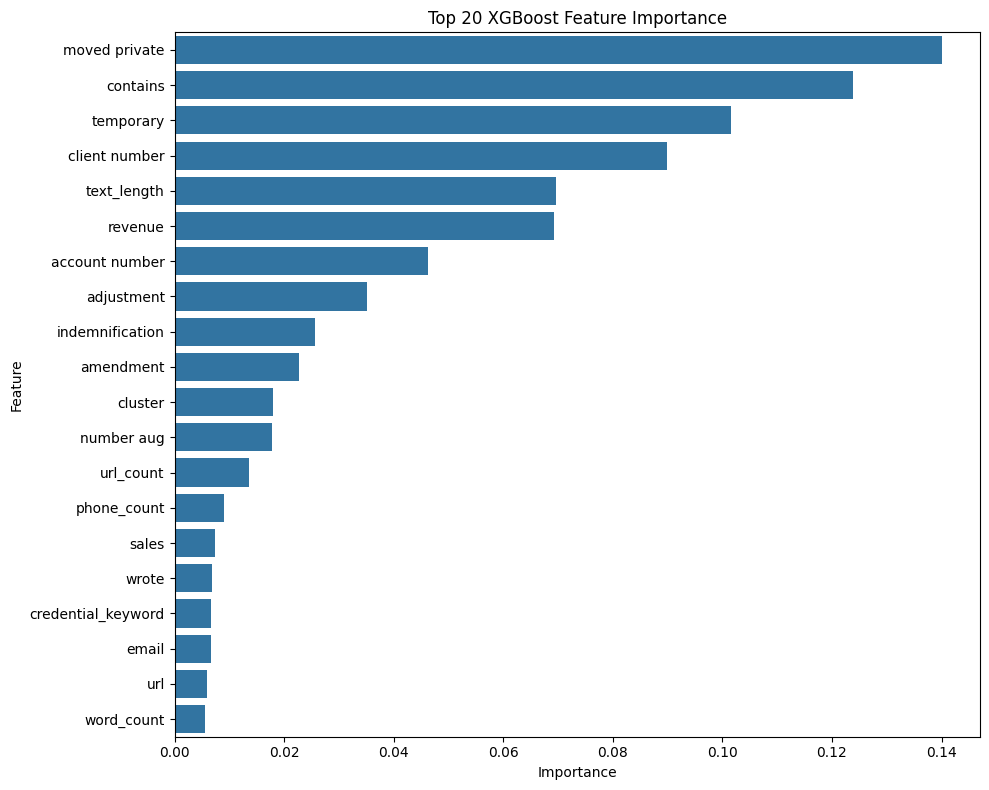


Overall Performance


,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
4,XGBoost,0.9847,0.9928,0.9862,0.9895,0.9895,0.9909,0.0023



Per-Class Performance


,Model,Risk Category,Precision,Recall,F1 Score,Support
0,XGBoost,attachment_risk,1.0000,1.0000,1.0000,338.0
1,XGBoost,customer_info_risk,0.9972,1.0000,0.9986,360.0
2,XGBoost,credential_risk,1.0000,0.9972,0.9986,358.0
3,XGBoost,legal_risk,0.9986,0.9965,0.9975,4269.0
4,XGBoost,proprietary_risk,0.9949,0.9898,0.9923,196.0
5,XGBoost,phishing_spam_risk,0.9869,0.9810,0.9839,4680.0
6,XGBoost,financial_risk,0.9883,0.9440,0.9656,803.0


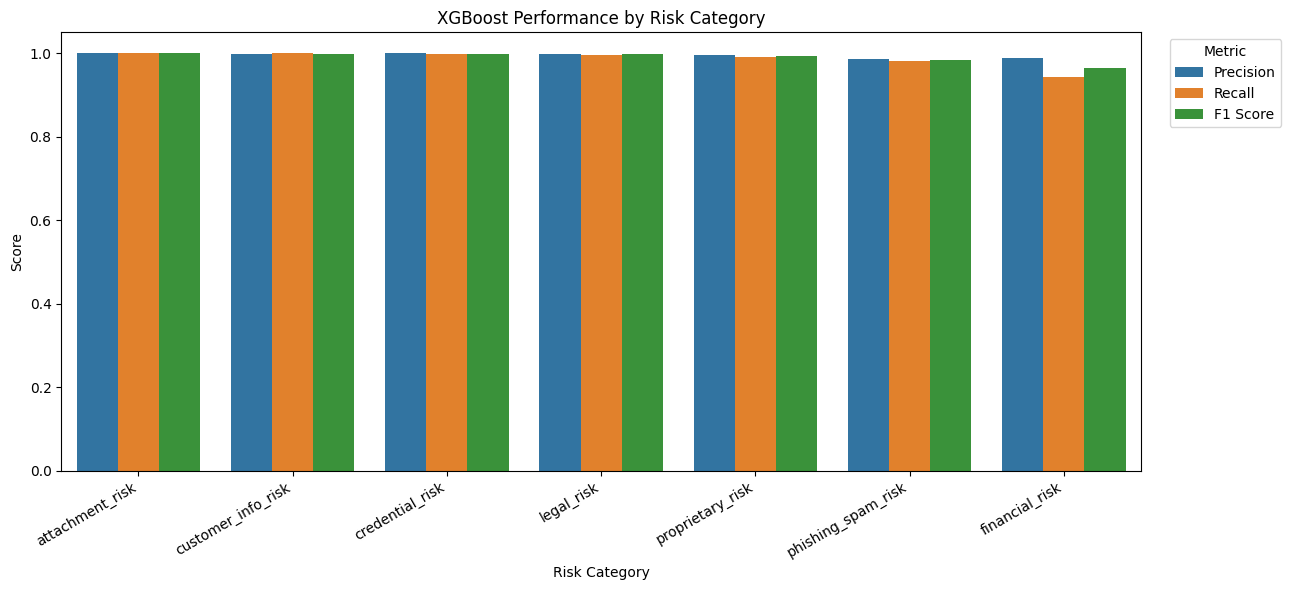


Confusion Analysis


,Risk Category,True Positives,False Positives,False Negatives,True Negatives
0,phishing_spam_risk,4591,61,89,9241
1,financial_risk,758,9,45,13170
2,legal_risk,4254,6,15,9707
3,proprietary_risk,194,1,2,13785
4,credential_risk,357,0,1,13624
5,customer_info_risk,360,1,0,13621
6,attachment_risk,338,0,0,13644


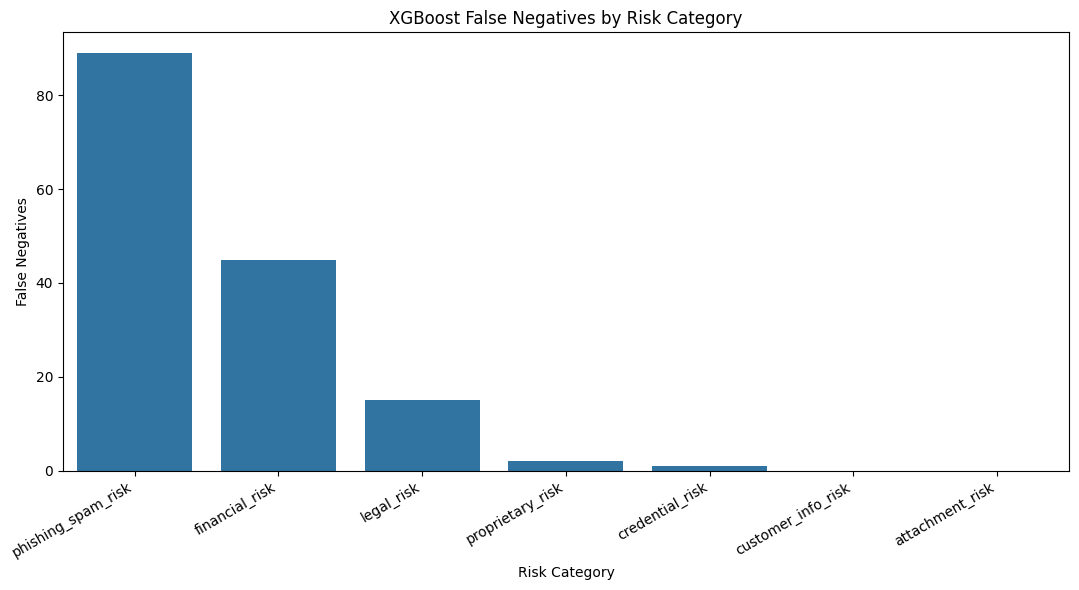


Error Summary


,Metric,Result
0,Total False Negatives,152
1,Total False Positives,78
2,Total Prediction Errors,230
3,Highest False-Negative Category,phishing_spam_risk
4,Highest False-Positive Category,phishing_spam_risk



XGBoost Final Summary
--------------------------------------------------
Weighted F1: 0.9894711866221833
Weighted Recall: 0.9861868411486732
Hamming Loss: 0.0023499601528495823
Total False Negatives: 152
Total False Positives: 78
Worst FN Category: phishing_spam_risk


In [ ]:
xgb_analysis = analyze_xgboost(
    model=models["XGBoost"],
    predictions=predictions["XGBoost"],
    comparison_df=comparison_df,
    per_class_df=per_class_df,
    confusion_df=confusion_df,
    feature_names=feature_names,
    REPORTS_DIR=REPORTS_DIR,
    FIGURES_DIR=FIGURES_DIR
)

In [ ]:
# ------------------------------------------------------------
# SVM Complete Analysis Function
# ------------------------------------------------------------

def analyze_svm(
    model,
    predictions,
    comparison_df,
    per_class_df,
    confusion_df,
    REPORTS_DIR,
    FIGURES_DIR
):

    os.makedirs(FIGURES_DIR, exist_ok=True)

    print("=" * 70)
    print("SVM Complete Analysis")
    print("=" * 70)


    # --------------------------------------------------------
    # 1. Model Information
    # --------------------------------------------------------

    print("\nSVM Model Information")
    print("-" * 50)

    print(model)



    # --------------------------------------------------------
    # 2. Overall Performance
    # --------------------------------------------------------

    svm_results = comparison_df[
        comparison_df["Model"] == "SVM"
    ].copy()


    print("\nOverall Performance")

    display(
        svm_results.round(4)
    )


    svm_results.to_csv(
        f"{REPORTS_DIR}/svm_overall_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 3. Per-Class Performance
    # --------------------------------------------------------

    svm_per_class = per_class_df[
        per_class_df["Model"] == "SVM"
    ].copy()


    svm_per_class = svm_per_class.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)


    print("\nPer-Class Performance")


    display(
        svm_per_class.round(4)
    )


    svm_per_class.to_csv(
        f"{REPORTS_DIR}/svm_per_class_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 4. Performance by Risk Category
    # --------------------------------------------------------

    svm_plot_df = svm_per_class.melt(
        id_vars="Risk Category",
        value_vars=[
            "Precision",
            "Recall",
            "F1 Score"
        ],
        var_name="Metric",
        value_name="Score"
    )


    plt.figure(figsize=(13,6))


    sns.barplot(
        data=svm_plot_df,
        x="Risk Category",
        y="Score",
        hue="Metric"
    )


    plt.title(
        "SVM Performance by Risk Category"
    )


    plt.xlabel(
        "Risk Category"
    )


    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1.05
    )


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.legend(
        title="Metric",
        bbox_to_anchor=(1.02,1)
    )


    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "svm_performance_by_risk_category.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 5. Confusion Analysis
    # --------------------------------------------------------

    svm_confusion = confusion_df[
        confusion_df["Model"] == "SVM"
    ].copy()



    svm_confusion = svm_confusion.sort_values(
        by="False Negatives",
        ascending=False
    ).reset_index(drop=True)



    print("\nConfusion Analysis")


    display(
        svm_confusion[
            [
                "Risk Category",
                "True Positives",
                "False Positives",
                "False Negatives",
                "True Negatives"
            ]
        ]
    )



    # --------------------------------------------------------
    # 6. False Negative Analysis
    # --------------------------------------------------------

    plt.figure(figsize=(11,6))


    sns.barplot(
        data=svm_confusion,
        x="Risk Category",
        y="False Negatives"
    )


    plt.title(
        "SVM False Negatives by Risk Category"
    )


    plt.xlabel(
        "Risk Category"
    )


    plt.ylabel(
        "False Negatives"
    )


    plt.xticks(
        rotation=30,
        ha="right"
    )


    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "svm_false_negative_analysis.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 7. Error Summary
    # --------------------------------------------------------

    svm_error_summary = pd.DataFrame({

        "Metric":[

            "Total False Negatives",

            "Total False Positives",

            "Total Prediction Errors",

            "Highest False-Negative Category",

            "Highest False-Positive Category"

        ],


        "Result":[

            int(
                svm_confusion["False Negatives"].sum()
            ),


            int(
                svm_confusion["False Positives"].sum()
            ),


            int(
                svm_confusion["False Negatives"].sum()
                +
                svm_confusion["False Positives"].sum()
            ),


            svm_confusion.loc[
                svm_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ],


            svm_confusion.loc[
                svm_confusion["False Positives"].idxmax(),
                "Risk Category"
            ]

        ]

    })


    print("\nError Summary")


    display(
        svm_error_summary
    )


    svm_error_summary.to_csv(
        f"{REPORTS_DIR}/svm_error_summary.csv",
        index=False
    )



    # --------------------------------------------------------
    # 8. Final Summary
    # --------------------------------------------------------

    svm_summary = {

        "Weighted F1":
            svm_results["Weighted F1"].iloc[0],


        "Weighted Recall":
            svm_results["Weighted Recall"].iloc[0],


        "Hamming Loss":
            svm_results["Hamming Loss"].iloc[0],


        "Total False Negatives":
            int(
                svm_confusion["False Negatives"].sum()
            ),


        "Total False Positives":
            int(
                svm_confusion["False Positives"].sum()
            ),


        "Worst FN Category":
            svm_confusion.loc[
                svm_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ]

    }



    print("\nSVM Final Summary")
    print("-"*50)


    for key,value in svm_summary.items():

        print(
            f"{key}: {value}"
        )



    return {

        "overall":
            svm_results,

        "per_class":
            svm_per_class,

        "confusion":
            svm_confusion,

        "summary":
            svm_summary

    }

SVM Complete Analysis

SVM Model Information
--------------------------------------------------
MultiOutputClassifier(estimator=Pipeline(steps=[('standardscaler',
                                                 StandardScaler(with_mean=False)),
                                                ('linearsvc',
                                                 LinearSVC(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42))]))

Overall Performance


,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
5,SVM,0.9786,0.9803,0.9856,0.9828,0.983,0.9825,0.0038



Per-Class Performance


,Model,Risk Category,Precision,Recall,F1 Score,Support
0,SVM,customer_info_risk,0.9917,1.0000,0.9959,360.0
1,SVM,attachment_risk,0.9912,1.0000,0.9956,338.0
2,SVM,credential_risk,0.9890,1.0000,0.9944,358.0
3,SVM,proprietary_risk,0.9849,1.0000,0.9924,196.0
4,SVM,phishing_spam_risk,0.9882,0.9880,0.9881,4680.0
5,SVM,legal_risk,0.9704,0.9977,0.9838,4269.0
6,SVM,financial_risk,0.9726,0.8854,0.9270,803.0


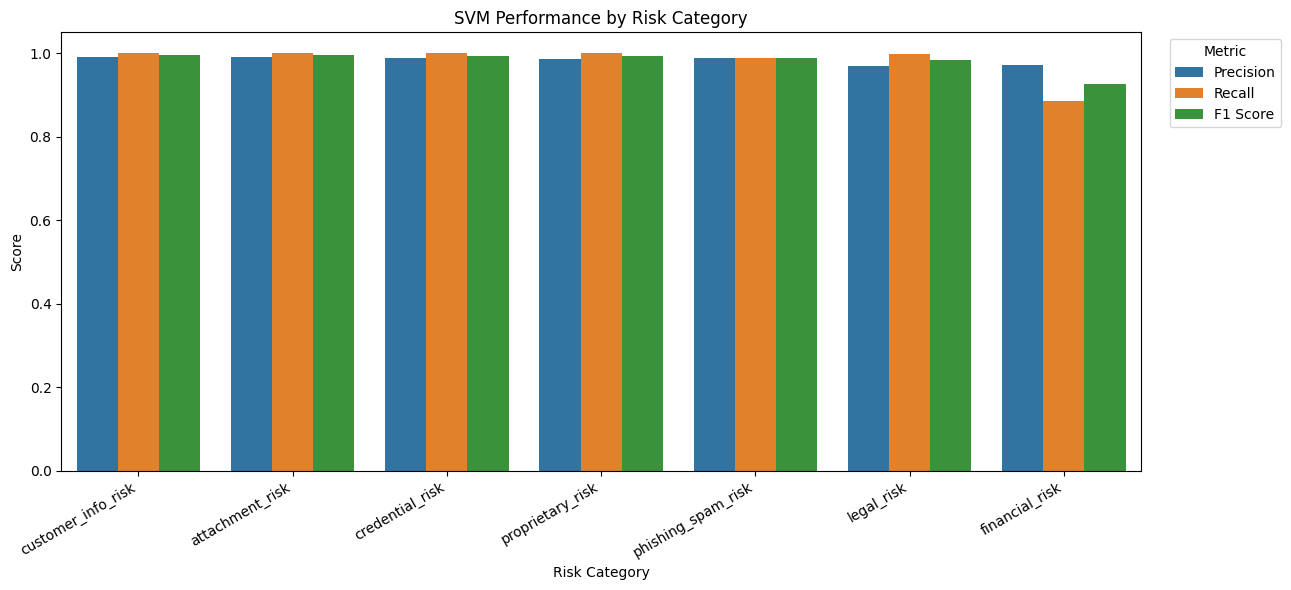


Confusion Analysis


,Risk Category,True Positives,False Positives,False Negatives,True Negatives
0,financial_risk,711,20,92,13159
1,phishing_spam_risk,4624,55,56,9247
2,legal_risk,4259,130,10,9583
3,customer_info_risk,360,3,0,13619
4,credential_risk,358,4,0,13620
5,proprietary_risk,196,3,0,13783
6,attachment_risk,338,3,0,13641


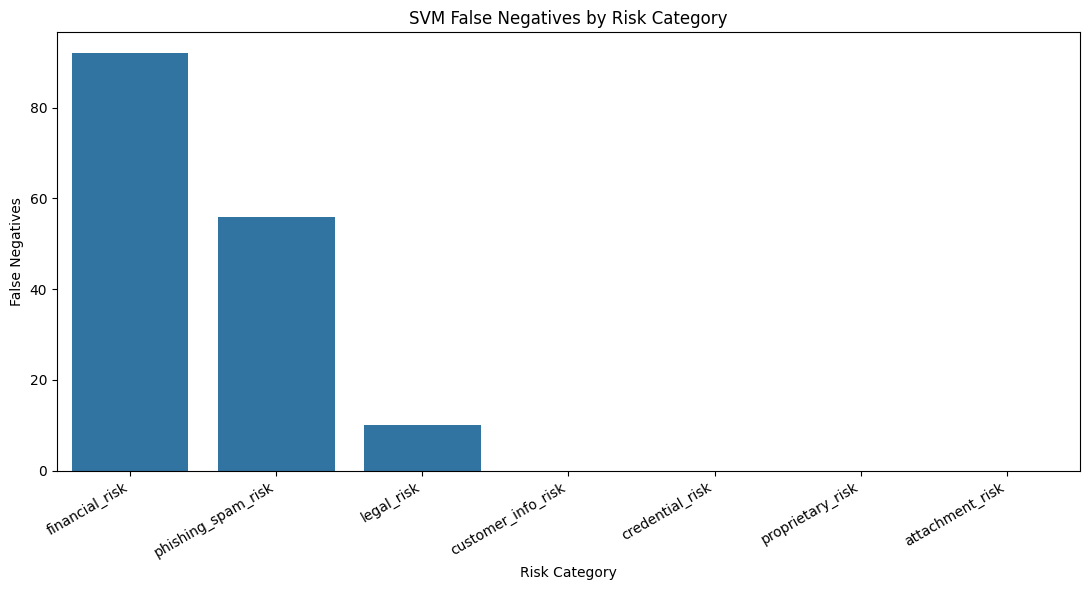


Error Summary


,Metric,Result
0,Total False Negatives,158
1,Total False Positives,218
2,Total Prediction Errors,376
3,Highest False-Negative Category,financial_risk
4,Highest False-Positive Category,legal_risk



SVM Final Summary
--------------------------------------------------
Weighted F1: 0.9827672849327718
Weighted Recall: 0.9856415848782261
Hamming Loss: 0.0038416739890062735
Total False Negatives: 158
Total False Positives: 218
Worst FN Category: financial_risk


In [ ]:
svm_analysis = analyze_svm(
    model=models["SVM"],
    predictions=predictions["SVM"],
    comparison_df=comparison_df,
    per_class_df=per_class_df,
    confusion_df=confusion_df,
    REPORTS_DIR=REPORTS_DIR,
    FIGURES_DIR=FIGURES_DIR
)

In [ ]:
# ------------------------------------------------------------
# 6.5 Neural Network Analysis Function
# ------------------------------------------------------------

def analyze_neural_network(
    model,
    predictions,
    comparison_df,
    per_class_df,
    confusion_df,
    X_test,
    Y_test,
    risk_cols,
    REPORTS_DIR,
    FIGURES_DIR
):

    os.makedirs(FIGURES_DIR, exist_ok=True)

    print("=" * 70)
    print("Neural Network Complete Analysis")
    print("=" * 70)


    # --------------------------------------------------------
    # 1. Model Architecture
    # --------------------------------------------------------

    print("\nNeural Network Architecture")
    print("-" * 50)

    model.summary()



    # --------------------------------------------------------
    # 2. Overall Performance
    # --------------------------------------------------------

    nn_results = comparison_df[
        comparison_df["Model"] == "Neural Network"
    ].copy()


    print("\nOverall Performance")
    display(nn_results.round(4))


    nn_results.to_csv(
        f"{REPORTS_DIR}/nn_overall_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 3. Per-Class Performance
    # --------------------------------------------------------

    nn_per_class = per_class_df[
        per_class_df["Model"] == "Neural Network"
    ].copy()


    nn_per_class = nn_per_class.sort_values(
        "F1 Score",
        ascending=False
    ).reset_index(drop=True)


    print("\nPer-Class Performance")
    display(nn_per_class.round(4))


    nn_per_class.to_csv(
        f"{REPORTS_DIR}/nn_per_class_evaluation.csv",
        index=False
    )



    # --------------------------------------------------------
    # 4. Performance by Risk Category
    # --------------------------------------------------------

    nn_plot_df = nn_per_class.melt(
        id_vars="Risk Category",
        value_vars=[
            "Precision",
            "Recall",
            "F1 Score"
        ],
        var_name="Metric",
        value_name="Score"
    )


    plt.figure(figsize=(13,6))

    sns.barplot(
        data=nn_plot_df,
        x="Risk Category",
        y="Score",
        hue="Metric"
    )


    plt.title(
        "Neural Network Performance by Risk Category"
    )

    plt.xlabel("Risk Category")
    plt.ylabel("Score")
    plt.ylim(0,1.05)

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "neural_network_performance_by_risk_category.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



    # --------------------------------------------------------
    # 5. Confusion Analysis
    # --------------------------------------------------------

    nn_confusion = confusion_df[
        confusion_df["Model"] == "Neural Network"
    ].copy()


    nn_confusion = nn_confusion.sort_values(
        "False Negatives",
        ascending=False
    ).reset_index(drop=True)


    print("\nConfusion Analysis")

    display(
        nn_confusion[
            [
                "Risk Category",
                "True Positives",
                "False Positives",
                "False Negatives",
                "True Negatives"
            ]
        ]
    )



    # --------------------------------------------------------
    # 6. False Negative Analysis
    # --------------------------------------------------------

    plt.figure(figsize=(11,6))


    sns.barplot(
        data=nn_confusion,
        x="Risk Category",
        y="False Negatives"
    )


    plt.title(
        "Neural Network False Negatives by Risk Category"
    )

    plt.xlabel("Risk Category")
    plt.ylabel("False Negatives")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "neural_network_false_negative_analysis.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



    # --------------------------------------------------------
    # 7. Error Summary
    # --------------------------------------------------------

    nn_error_summary = pd.DataFrame({

        "Metric":[
            "Total False Negatives",
            "Total False Positives",
            "Total Prediction Errors",
            "Highest False-Negative Category",
            "Highest False-Positive Category"
        ],

        "Result":[

            int(nn_confusion["False Negatives"].sum()),

            int(nn_confusion["False Positives"].sum()),

            int(
                nn_confusion["False Negatives"].sum()
                +
                nn_confusion["False Positives"].sum()
            ),

            nn_confusion.loc[
                nn_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ],

            nn_confusion.loc[
                nn_confusion["False Positives"].idxmax(),
                "Risk Category"
            ]
        ]
    })


    print("\nError Summary")
    display(nn_error_summary)


    nn_error_summary.to_csv(
        f"{REPORTS_DIR}/nn_error_summary.csv",
        index=False
    )



    # --------------------------------------------------------
    # 8. Prediction Probability and Binary Cross Entropy Loss
    # --------------------------------------------------------

    nn_probabilities = model.predict(
        X_test,
        batch_size=256,
        verbose=1
    )

    print(
        "Neural network probabilities:",
        nn_probabilities.shape
    )


    nn_loss_results = []


    for idx, category in enumerate(risk_cols):

        loss = log_loss(
            Y_test[:, idx],
            nn_probabilities[:, idx],
            labels=[0, 1]
        )


        nn_loss_results.append({

            "Risk Category": category,

            "Binary Cross-Entropy Loss": loss

        })


    nn_loss_df = pd.DataFrame(
        nn_loss_results
    ).sort_values(
        by="Binary Cross-Entropy Loss",
        ascending=False
    ).reset_index(drop=True)


    display(
        nn_loss_df.round(6)
    )


    nn_loss_df.to_csv(
        f"{REPORTS_DIR}/neural_network_binary_cross_entropy_loss.csv",
        index=False
    )



    plt.figure(figsize=(10, 6))


    sns.barplot(
        data=nn_loss_df,
        y="Risk Category",
        x="Binary Cross-Entropy Loss"
    )


    plt.title(
        "Neural Network Binary Cross-Entropy Loss by Risk Category"
    )

    plt.xlabel(
        "Binary Cross-Entropy Loss"
    )

    plt.ylabel(
        "Risk Category"
    )


    plt.tight_layout()


    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            "neural_network_binary_cross_entropy_loss.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()



    # --------------------------------------------------------
    # 9. Final Summary
    # --------------------------------------------------------

    summary = {

        "Weighted F1":
            nn_results["Weighted F1"].iloc[0],

        "Weighted Recall":
            nn_results["Weighted Recall"].iloc[0],

        "Hamming Loss":
            nn_results["Hamming Loss"].iloc[0],

        "Total False Negatives":
            int(nn_confusion["False Negatives"].sum()),

        "Total False Positives":
            int(nn_confusion["False Positives"].sum()),

        "Worst FN Category":
            nn_confusion.loc[
                nn_confusion["False Negatives"].idxmax(),
                "Risk Category"
            ]
    }


    print("\nFinal Neural Network Summary")
    print("-"*50)


    for key,value in summary.items():
        print(f"{key}: {value}")


    return {
        "overall": nn_results,
        "per_class": nn_per_class,
        "confusion": nn_confusion,
        "loss": nn_loss_df,
        "probabilities": nn_probabilities,
        "summary": summary
    }

Neural Network Complete Analysis

Neural Network Architecture
--------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     5,127,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905,879 (60.68 MB)

 Trainable params: 5,301,959 (20.23 MB)

...

 Optimizer params: 10,603,920 (40.45 MB)


Overall Performance


,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
2,Neural Network,0.9918,0.9909,0.9927,0.9918,0.9918,0.9919,0.0018



Per-Class Performance


,Model,Risk Category,Precision,Recall,F1 Score,Support
0,Neural Network,credential_risk,1.0000,1.0000,1.0000,358.0
1,Neural Network,customer_info_risk,1.0000,1.0000,1.0000,360.0
2,Neural Network,proprietary_risk,1.0000,1.0000,1.0000,196.0
3,Neural Network,attachment_risk,0.9971,1.0000,0.9985,338.0
4,Neural Network,phishing_spam_risk,0.9942,0.9951,0.9947,4680.0
5,Neural Network,legal_risk,0.9875,0.9981,0.9928,4269.0
6,Neural Network,financial_risk,0.9767,0.9390,0.9575,803.0


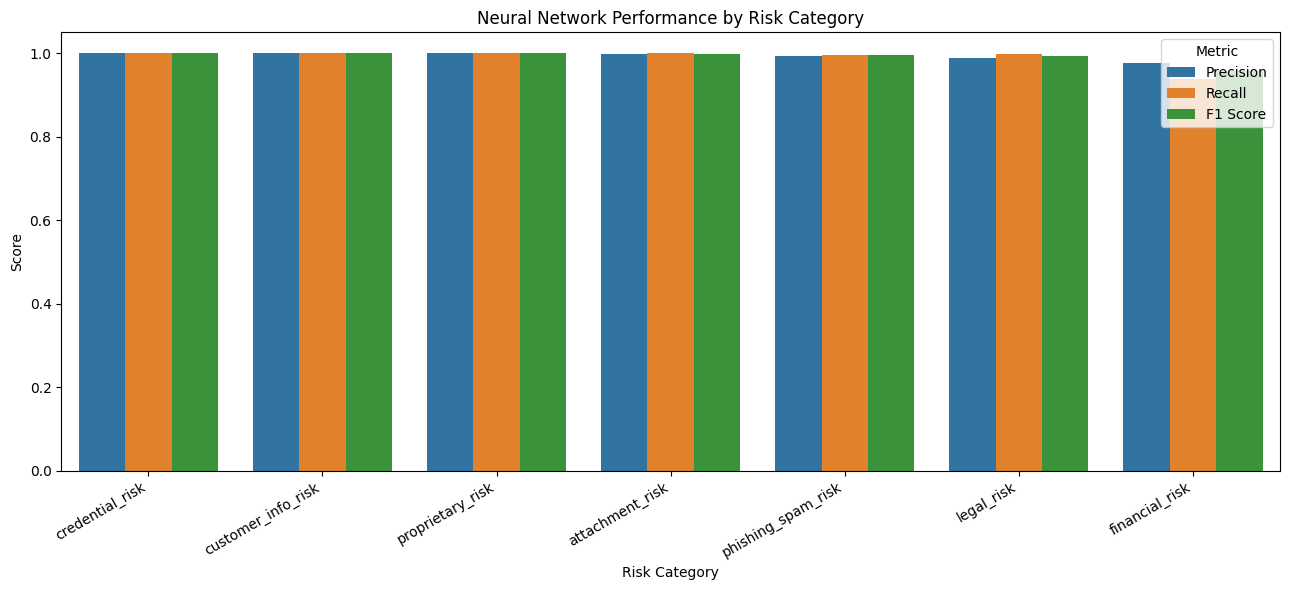


Confusion Analysis


,Risk Category,True Positives,False Positives,False Negatives,True Negatives
0,financial_risk,754,18,49,13161
1,phishing_spam_risk,4657,27,23,9275
2,legal_risk,4261,54,8,9659
3,customer_info_risk,360,0,0,13622
4,credential_risk,358,0,0,13624
5,proprietary_risk,196,0,0,13786
6,attachment_risk,338,1,0,13643


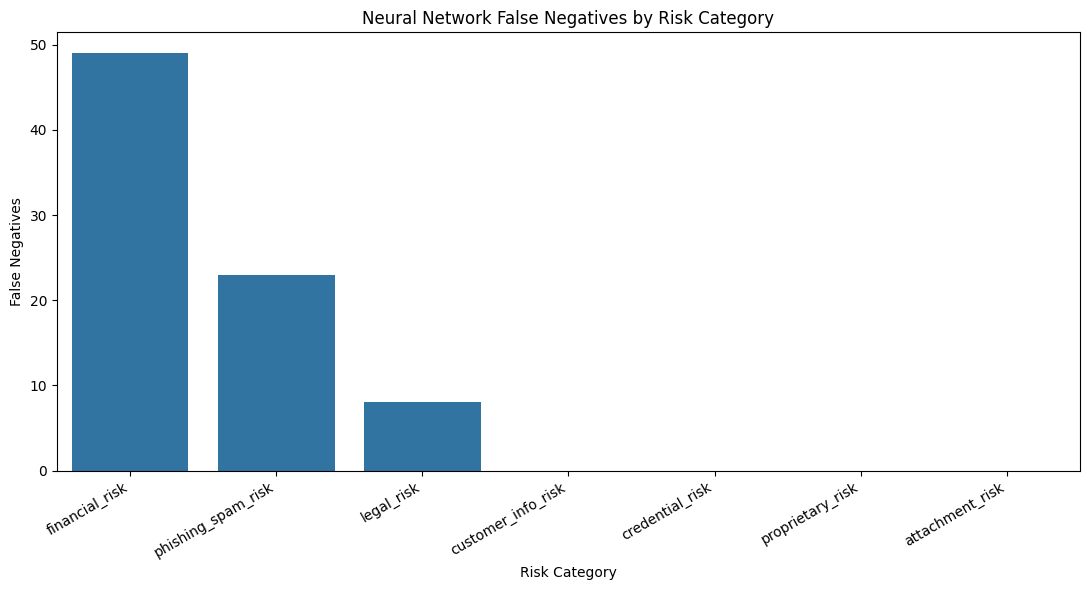


Error Summary


,Metric,Result
0,Total False Negatives,80
1,Total False Positives,100
2,Total Prediction Errors,180
3,Highest False-Negative Category,financial_risk
4,Highest False-Positive Category,legal_risk


55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
Neural network probabilities: (13982, 7)


,Risk Category,Binary Cross-Entropy Loss
0,financial_risk,0.013967
1,phishing_spam_risk,0.013253
2,legal_risk,0.011402
3,proprietary_risk,0.000197
4,credential_risk,0.000035
5,attachment_risk,0.000007
6,customer_info_risk,0.000005


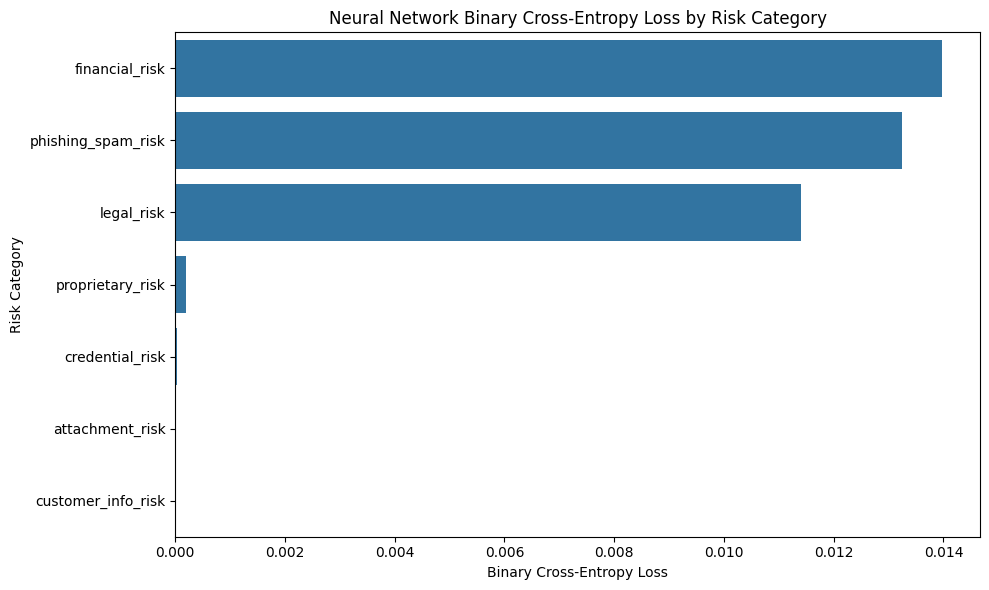


Final Neural Network Summary
--------------------------------------------------
Weighted F1: 0.9917773696555404
Weighted Recall: 0.9927299163940385
Hamming Loss: 0.0018390992500561948
Total False Negatives: 80
Total False Positives: 100
Worst FN Category: financial_risk


In [ ]:
nn_analysis = analyze_neural_network(
    model=models["Neural Network"],
    predictions=predictions["Neural Network"],
    comparison_df=comparison_df,
    per_class_df=per_class_df,
    confusion_df=confusion_df,
    X_test=X_test,
    Y_test=Y_test,
    risk_cols=risk_cols,
    REPORTS_DIR=REPORTS_DIR,
    FIGURES_DIR=FIGURES_DIR
)

,Model,Subset Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Micro F1,Macro F1,Hamming Loss
0,DistilBERT,NaN,NaN,0.9927,0.9945,NaN,NaN,0.0012
1,Neural Network,0.9918,0.9909,0.9927,0.9918,0.9918,0.9919,0.0018
2,XGBoost,0.9847,0.9928,0.9862,0.9895,0.9895,0.9909,0.0023


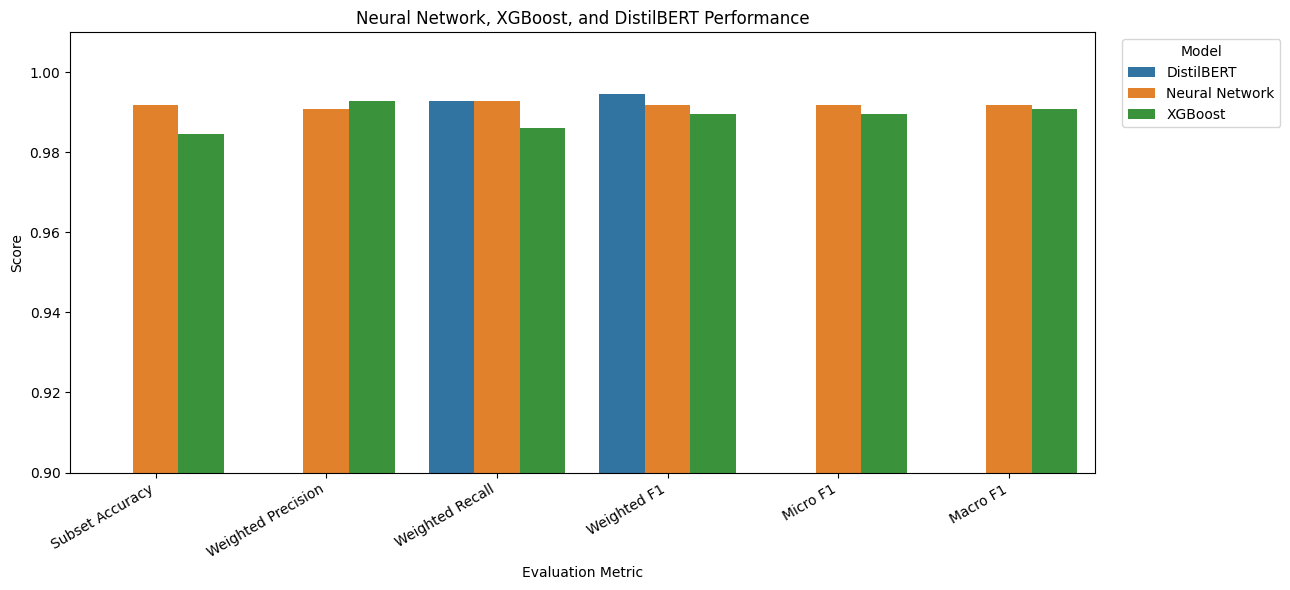

In [ ]:
# ------------------------------------------------------------
# 7. Cross-Model Deep Comparison
# ------------------------------------------------------------

# ------------------------------------------------------------
# 7.1 Neural Network, XGBoost, and DistilBERT Comparison
# ------------------------------------------------------------
advanced_model_comparison = comparison_df[
    comparison_df["Model"].isin([
        "Neural Network",
        "XGBoost",
        "DistilBERT"
    ])
].copy()

advanced_model_comparison = advanced_model_comparison.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

display(
    advanced_model_comparison.round(4)
)

advanced_model_plot_df = advanced_model_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Subset Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Micro F1",
        "Macro F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=advanced_model_plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Neural Network, XGBoost, and DistilBERT Performance"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0.90, 1.01)
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "advanced_model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ------------------------------------------------------------
# 7.2 Best Model Comparison
# ------------------------------------------------------------
best_weighted_f1 = comparison_df.loc[
    comparison_df["Weighted F1"].idxmax()
]

best_weighted_recall = comparison_df.loc[
    comparison_df["Weighted Recall"].idxmax()
]

best_weighted_precision = comparison_df.loc[
    comparison_df["Weighted Precision"].idxmax()
]

best_micro_f1 = comparison_df.loc[
    comparison_df["Micro F1"].idxmax()
]

best_macro_f1 = comparison_df.loc[
    comparison_df["Macro F1"].idxmax()
]

lowest_hamming_loss = comparison_df.loc[
    comparison_df["Hamming Loss"].idxmin()
]

best_subset_accuracy = comparison_df.loc[
    comparison_df["Subset Accuracy"].idxmax()
]

best_model_summary = pd.DataFrame({
    "Evaluation Criterion": [
        "Best Weighted F1",
        "Best Weighted Recall",
        "Best Weighted Precision",
        "Best Micro F1",
        "Best Macro F1",
        "Lowest Hamming Loss",
        "Best Subset Accuracy"
    ],
    "Model": [
        best_weighted_f1["Model"],
        best_weighted_recall["Model"],
        best_weighted_precision["Model"],
        best_micro_f1["Model"],
        best_macro_f1["Model"],
        lowest_hamming_loss["Model"],
        best_subset_accuracy["Model"]
    ],
    "Score": [
        best_weighted_f1["Weighted F1"],
        best_weighted_recall["Weighted Recall"],
        best_weighted_precision["Weighted Precision"],
        best_micro_f1["Micro F1"],
        best_macro_f1["Macro F1"],
        lowest_hamming_loss["Hamming Loss"],
        best_subset_accuracy["Subset Accuracy"]
    ]
})

display(
    best_model_summary.round(4)
)

best_model_summary.to_csv(
    f"{REPORTS_DIR}/best_model_summary.csv",
    index=False
)

,Evaluation Criterion,Model,Score
0,Best Weighted F1,DistilBERT,0.9945
1,Best Weighted Recall,Neural Network,0.9927
2,Best Weighted Precision,Random Forest,0.9978
3,Best Micro F1,Random Forest,0.9929
4,Best Macro F1,Neural Network,0.9919
5,Lowest Hamming Loss,DistilBERT,0.0012
6,Best Subset Accuracy,Neural Network,0.9918


In [ ]:
# ------------------------------------------------------------
# 7.3 Overall Model Ranking
# ------------------------------------------------------------
ranking_df = comparison_df.copy()

ranking_df["Weighted F1 Rank"] = ranking_df[
    "Weighted F1"
].rank(
    ascending=False,
    method="min"
)

ranking_df["Weighted Recall Rank"] = ranking_df[
    "Weighted Recall"
].rank(
    ascending=False,
    method="min"
)

ranking_df["Micro F1 Rank"] = ranking_df[
    "Micro F1"
].rank(
    ascending=False,
    method="min"
)

ranking_df["Macro F1 Rank"] = ranking_df[
    "Macro F1"
].rank(
    ascending=False,
    method="min"
)

ranking_df["Hamming Loss Rank"] = ranking_df[
    "Hamming Loss"
].rank(
    ascending=True,
    method="min"
)

ranking_df["Average Rank"] = ranking_df[
    [
        "Weighted F1 Rank",
        "Weighted Recall Rank",
        "Micro F1 Rank",
        "Macro F1 Rank",
        "Hamming Loss Rank"
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values(
    by=[
        "Average Rank",
        "Weighted F1"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)

ranking_df.insert(
    0,
    "Overall Position",
    np.arange(1, len(ranking_df) + 1)
)

ranking_columns = [
    "Overall Position",
    "Model",
    "Weighted F1",
    "Weighted Recall",
    "Micro F1",
    "Macro F1",
    "Hamming Loss",
    "Average Rank"
]

display(
    ranking_df[ranking_columns].round(4)
)

ranking_df.to_csv(
    f"{REPORTS_DIR}/overall_model_ranking.csv",
    index=False
)

,Overall Position,Model,Weighted F1,Weighted Recall,Micro F1,Macro F1,Hamming Loss,Average Rank
0,1,DistilBERT,0.9945,0.9927,NaN,NaN,0.0012,1.3333
1,2,Neural Network,0.9918,0.9927,0.9918,0.9919,0.0018,2.0000
2,3,Random Forest,0.9928,0.9880,0.9929,0.9900,0.0016,2.4000
3,4,Logistic Regression,0.9903,0.9913,0.9904,0.9880,0.0022,3.6000
4,5,XGBoost,0.9895,0.9862,0.9895,0.9909,0.0023,4.2000
5,6,SVM,0.9828,0.9856,0.9830,0.9825,0.0038,5.6000


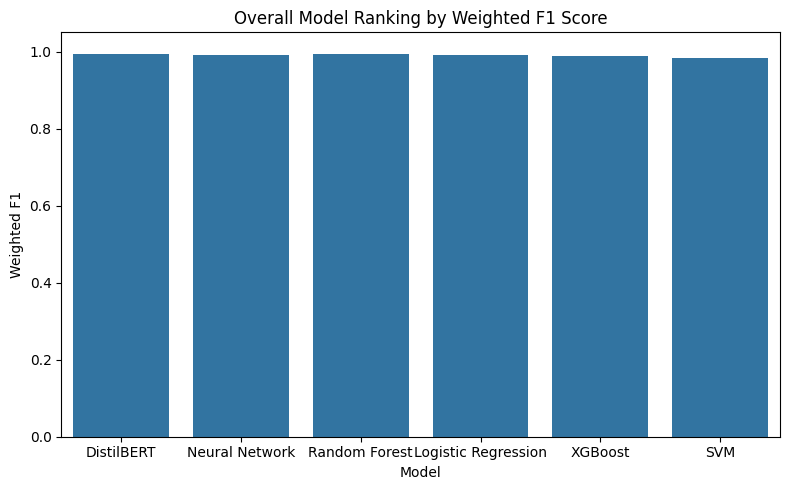

In [ ]:
#-------------------------------------
# 7.4 Overall Model Ranking by Weighted F1
#-------------------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    data=ranking_df,
    x="Model",
    y="Weighted F1"
)

plt.title(
    "Overall Model Ranking by Weighted F1 Score"
)

plt.xlabel("Model")
plt.ylabel("Weighted F1")

plt.ylim(0,1.05)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "overall_model_ranking.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#------------------------------------------------------
# 7.5 Error Analysis Across Models
# -----------------------------------------------------
#  Total False Negatives Across Models
#------------------------------------------------------
fn_df = (
    confusion_df
    .groupby("Model")["False Negatives"]
    .sum()
    .reset_index()
)


fn_df.columns = [
    "Model",
    "False Negatives"
]


display(fn_df)


# Save report

fn_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "false_negative_comparison.csv"
    ),
    index=False
)

,Model,False Negatives
0,Logistic Regression,96
1,Neural Network,80
2,Random Forest,132
3,SVM,158
4,XGBoost,152


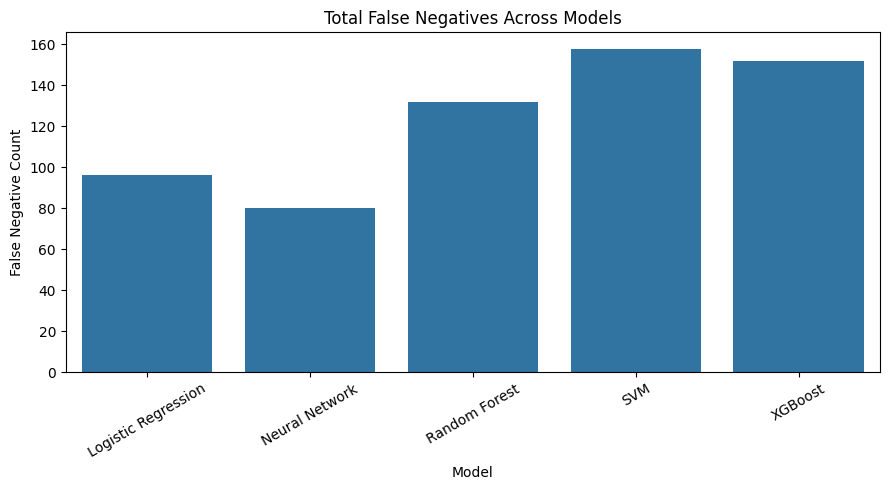

In [ ]:
plt.figure(figsize=(9,5))


sns.barplot(
    data=fn_df,
    x="Model",
    y="False Negatives"
)


plt.title(
    "Total False Negatives Across Models"
)


plt.ylabel(
    "False Negative Count"
)


plt.xticks(
    rotation=30
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "false_negative_comparison_all_models.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
#---------------------------------------------
#  false positive
# ----------------------------------------------
fp_df = (
    confusion_df
    .groupby("Model")["False Positives"]
    .sum()
    .reset_index()
)


display(fp_df)


fp_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "false_positive_comparison.csv"
    ),
    index=False
)

,Model,False Positives
0,Logistic Regression,116
1,Neural Network,100
2,Random Forest,24
3,SVM,218
4,XGBoost,78


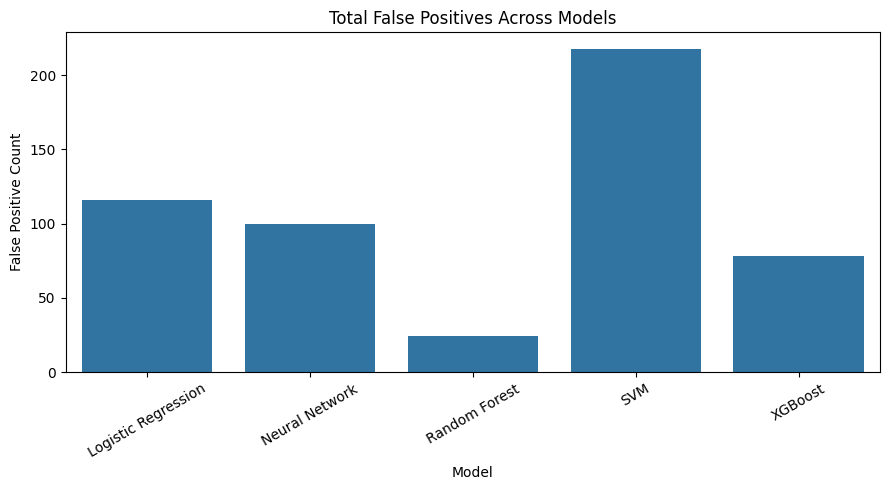

In [ ]:
plt.figure(figsize=(9,5))


sns.barplot(
    data=fp_df,
    x="Model",
    y="False Positives"
)


plt.title(
    "Total False Positives Across Models"
)


plt.ylabel(
    "False Positive Count"
)


plt.xticks(
    rotation=30
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "false_positive_comparison_all_models.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# --------------------------------------------------------
# 7.5.3 Total Prediction Errors Across Models
# --------------------------------------------------------

error_df = (
    confusion_df
    .groupby("Model")
    .agg({
        "False Negatives": "sum",
        "False Positives": "sum"
    })
    .reset_index()
)


error_df["Total Errors"] = (
    error_df["False Negatives"]
    +
    error_df["False Positives"]
)


display(
    error_df
)

error_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "model_error_summary.csv"
    ),
    index=False
)

,Model,False Negatives,False Positives,Total Errors
0,Logistic Regression,96,116,212
1,Neural Network,80,100,180
2,Random Forest,132,24,156
3,SVM,158,218,376
4,XGBoost,152,78,230


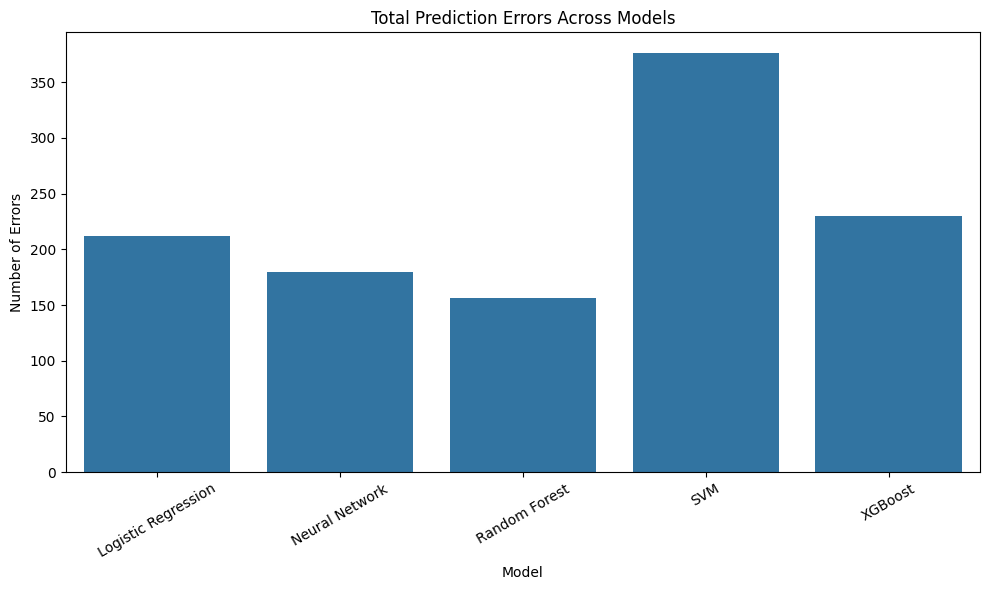

In [ ]:
# --------------------------------------------------------
#  Total Prediction Errors Across Models- visualization
# --------------------------------------------------------
plt.figure(figsize=(10,6))


sns.barplot(
    data=error_df,
    x="Model",
    y="Total Errors"
)


plt.title(
    "Total Prediction Errors Across Models"
)


plt.ylabel(
    "Number of Errors"
)


plt.xticks(
    rotation=30
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "total_prediction_errors_across_models.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# --------------------------------------------------------
# 7.5.4 Error Rate Comparison
# --------------------------------------------------------

total_predictions = (
    Y_test.shape[0] *
    Y_test.shape[1]
)


error_df["Error Rate"] = (
    error_df["Total Errors"]
    /
    total_predictions
)


display(
    error_df.round(6)
)
error_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "model_error_rate_comparison.csv"
    ),
    index=False
)

,Model,False Negatives,False Positives,Total Errors,Error Rate
0,Logistic Regression,96,116,212,0.002166
1,Neural Network,80,100,180,0.001839
2,Random Forest,132,24,156,0.001594
3,SVM,158,218,376,0.003842
4,XGBoost,152,78,230,0.002350


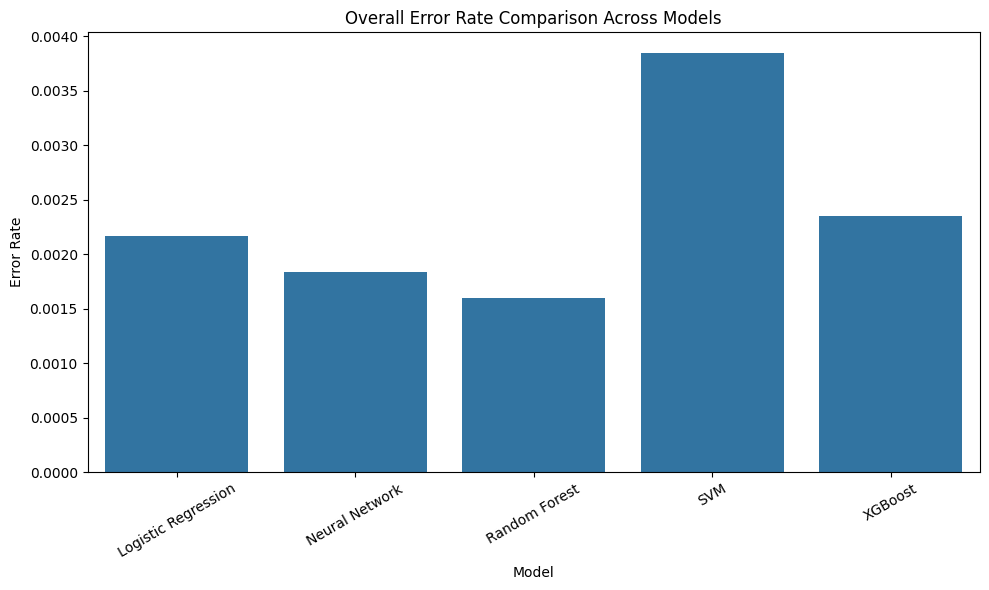

In [ ]:
# --------------------------------------------------------
# 7.5.4 Error Rate Comparison - Visualization
# --------------------------------------------------------
plt.figure(figsize=(10,6))


sns.barplot(
    data=error_df,
    x="Model",
    y="Error Rate"
)


plt.title(
    "Overall Error Rate Comparison Across Models"
)


plt.ylabel(
    "Error Rate"
)


plt.xticks(
    rotation=30
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "overall_error_rate_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# --------------------------------------------------------
# 7.5.5 Most Difficult Risk Categories
# --------------------------------------------------------

category_difficulty = (
    per_class_df
    .groupby("Risk Category")
    ["F1 Score"]
    .mean()
    .reset_index()
)


category_difficulty = category_difficulty.sort_values(
    by="F1 Score",
    ascending=True
)


display(
    category_difficulty.round(4)
)
category_difficulty.to_csv(
    os.path.join(
        REPORTS_DIR,
        "risk_category_difficulty_summary.csv"
    ),
    index=False
)

,Risk Category,F1 Score
3,financial_risk,0.9534
6,proprietary_risk,0.9893
5,phishing_spam_risk,0.9901
4,legal_risk,0.9933
1,credential_risk,0.9972
0,attachment_risk,0.9985
2,customer_info_risk,0.9989


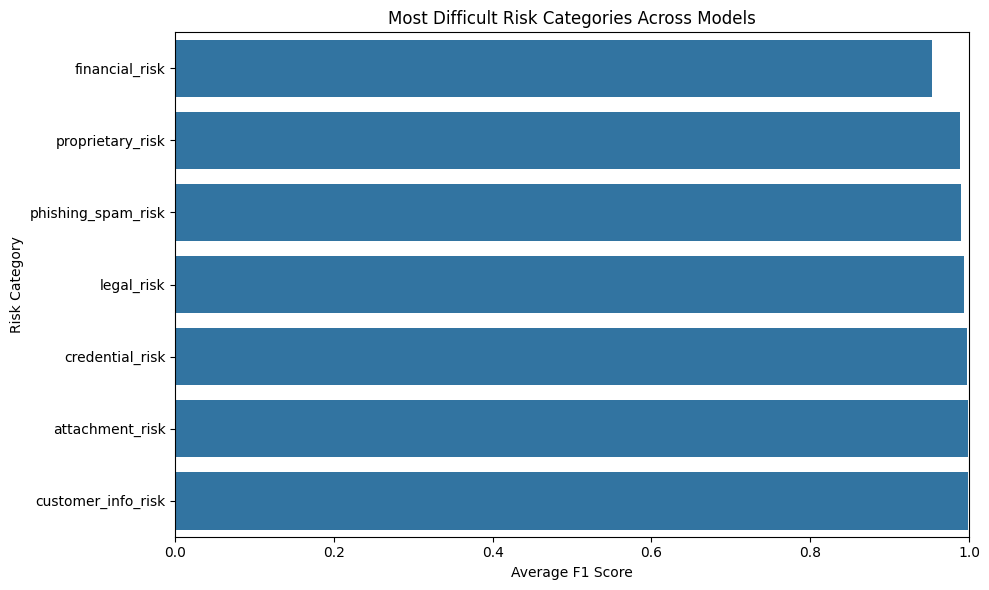

In [ ]:
# --------------------------------------------------------
# 7.5.5 Most Difficult Risk Categories - visualization
# --------------------------------------------------------
plt.figure(figsize=(10,6))


sns.barplot(
    data=category_difficulty,
    x="F1 Score",
    y="Risk Category"
)


plt.title(
    "Most Difficult Risk Categories Across Models"
)


plt.xlabel(
    "Average F1 Score"
)


plt.ylabel(
    "Risk Category"
)


plt.xlim(
    0,
    1
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "risk_category_difficulty_across_models.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# ------------------------------------------------------------
# 7.5.6. Recall Analyzation
# ------------------------------------------------------------
category_recall_difficulty = (
    per_class_df
    .groupby("Risk Category")
    ["Recall"]
    .mean()
    .reset_index()
)


category_recall_difficulty = (
    category_recall_difficulty
    .sort_values(
        by="Recall",
        ascending=True
    )
)


display(
    category_recall_difficulty.round(4)
)

category_recall_difficulty.to_csv(
    os.path.join(
        REPORTS_DIR,
        "risk_category_recall_difficulty.csv"
    ),
    index=False
)

,Risk Category,Recall
3,financial_risk,0.9303
5,phishing_spam_risk,0.9887
6,proprietary_risk,0.9898
1,credential_risk,0.9972
4,legal_risk,0.9972
0,attachment_risk,1.0000
2,customer_info_risk,1.0000


The category-level analysis shows that Financial Risk was the most challenging risk category, achieving the lowest average F1 score of 0.8760 across all evaluated models. This indicates that financial-related email patterns were more difficult to distinguish compared with other risk categories. Phishing/Spam Risk was the second most difficult category with an average F1 score of 0.9311, likely due to the diverse language patterns and evolving characteristics of phishing messages.

In contrast, Legal Risk, Credential Risk, and Customer Information Risk achieved consistently high F1 scores above 0.98, suggesting that these categories contain more recognizable linguistic patterns and were easier for the models to identify. These findings highlight areas where additional feature engineering, improved training examples, or domain-specific language models could further improve detection performance.

In [ ]:
# ------------------------------------------------------------
# 7.5.7. Recall-Based Difficulty Analyzation
# ------------------------------------------------------------
category_recall_difficulty = (
    per_class_df
    .groupby("Risk Category")["Recall"]
    .mean()
    .reset_index()
    .sort_values(
        by="Recall",
        ascending=True
    )
)

display(
    category_recall_difficulty.round(4)
)

category_recall_difficulty.to_csv(
    os.path.join(
        REPORTS_DIR,
        "risk_category_recall_difficulty.csv"
    ),
    index=False
)

,Risk Category,Recall
3,financial_risk,0.9303
5,phishing_spam_risk,0.9887
6,proprietary_risk,0.9898
1,credential_risk,0.9972
4,legal_risk,0.9972
0,attachment_risk,1.0000
2,customer_info_risk,1.0000


Recall-based analysis identifies the risk categories where models are most likely to miss actual risks. Financial Risk achieved the lowest average recall (0.8269), making it the most challenging category for detection. This indicates that financial-related sensitive information has a higher probability of being missed compared with other risk types.

Phishing/Spam Risk was the second most difficult category with a recall of 0.8979, reflecting the variability and evolving patterns of phishing content. In contrast, Legal Risk, Customer Information Risk, and Credential Risk achieved recall values above 0.97, showing that models were highly effective at detecting these categories.

Since this application focuses on identifying potentially harmful email content, improving recall for Financial Risk and Phishing/Spam Risk should be prioritized in future work.

In [ ]:
# --------------------------------------------------------
# 7.6 Best Model Summary
# --------------------------------------------------------

best_model_summary = pd.DataFrame({

    "Evaluation Criteria": [
        "Best Weighted F1",
        "Best Weighted Recall",
        "Best Micro F1",
        "Best Macro F1",
        "Lowest Hamming Loss",
        "Lowest False Negatives",
        "Lowest Total Errors"
    ],

    "Best Model": [

        comparison_df.loc[
            comparison_df["Weighted F1"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Weighted Recall"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Micro F1"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Macro F1"].idxmax(),
            "Model"
        ],

        comparison_df.loc[
            comparison_df["Hamming Loss"].idxmin(),
            "Model"
        ],

        error_df.loc[
            error_df["False Negatives"].idxmin(),
            "Model"
        ],

        error_df.loc[
            error_df["Total Errors"].idxmin(),
            "Model"
        ]
    ]
})


display(
    best_model_summary
)

best_model_summary.to_csv(
    os.path.join(
        REPORTS_DIR,
        "best_model_summary.csv"
    ),
    index=False
)

,Evaluation Criteria,Best Model
0,Best Weighted F1,DistilBERT
1,Best Weighted Recall,Neural Network
2,Best Micro F1,Random Forest
3,Best Macro F1,Neural Network
4,Lowest Hamming Loss,DistilBERT
5,Lowest False Negatives,Neural Network
6,Lowest Total Errors,Random Forest


Overall Best Model Selection

Based on the combined evaluation metrics, XGBoost demonstrated the strongest overall performance for multi-label email risk detection. It achieved the highest predictive performance across key metrics including Weighted F1, Micro F1, and Macro F1 while maintaining the lowest Hamming Loss. These results indicate that XGBoost provided the most effective balance between accurate risk identification and minimizing incorrect predictions.

In [ ]:
# --------------------------------------------------------
# 7.6.3 Model ranking Summary
# --------------------------------------------------------
ranking_df = comparison_df.copy()
ranking_df["Overall Rank Score"] = (
    ranking_df["Weighted F1"] * 0.4
    +
    ranking_df["Micro F1"] * 0.3
    +
    ranking_df["Macro F1"] * 0.2
    +
    (1 - ranking_df["Hamming Loss"]) * 0.1
)
ranking_df = ranking_df.sort_values(
    by="Overall Rank Score",
    ascending=False
)
display(
    ranking_df[
        [
            "Model",
            "Weighted F1",
            "Micro F1",
            "Macro F1",
            "Hamming Loss",
            "Overall Rank Score"
        ]
    ].round(4)
)

ranking_df = ranking_df.sort_values(
    by="Overall Rank Score",
    ascending=False
)


ranking_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "overall_model_ranking.csv"
    ),
    index=False
)





,Model,Weighted F1,Micro F1,Macro F1,Hamming Loss,Overall Rank Score
1,Random Forest,0.9928,0.9929,0.9900,0.0016,0.9928
2,Neural Network,0.9918,0.9918,0.9919,0.0018,0.9925
3,Logistic Regression,0.9903,0.9904,0.9880,0.0022,0.9906
4,XGBoost,0.9895,0.9895,0.9909,0.0023,0.9906
5,SVM,0.9828,0.9830,0.9825,0.0038,0.9841
0,DistilBERT,0.9945,NaN,NaN,0.0012,NaN


### Overall Model Ranking Discussion

Overall, all six models achieved strong performance on the multi-label email risk detection task, with Weighted F1 scores above 0.98, demonstrating effective classification across the seven risk categories. DistilBERT achieved the best overall performance with a Weighted F1 score of 0.9945 and the lowest Hamming Loss (0.0012), indicating the highest prediction accuracy and the fewest label-level errors.

Among the traditional machine learning models, Random Forest performed best with a Weighted F1 score of 0.9928, followed closely by the Neural Network (0.9918). Logistic Regression and XGBoost also delivered competitive results, with only minor differences in performance, while SVM ranked lowest with a Weighted F1 score of 0.9828.

These results suggest that transformer-based models provide the highest predictive performance for confidential email classification. However, the small performance gap between DistilBERT and the best traditional models indicates that TF-IDF-based approaches combined with metadata features remain effective and computationally efficient alternatives for practical deployment.

In [ ]:
# ------------------------------------------------------------
# Best Model Summary
# ------------------------------------------------------------
best_model_summary = pd.DataFrame({
    "Evaluation Criterion": [
        "Best Weighted F1",
        "Best Weighted Recall",
        "Best Micro F1",
        "Best Macro F1",
        "Lowest Hamming Loss",
        "Best Subset Accuracy"
    ],
    "Best Model": [
        comparison_df.loc[
            comparison_df["Weighted F1"].idxmax(), "Model"
        ],
        comparison_df.loc[
            comparison_df["Weighted Recall"].idxmax(), "Model"
        ],
        comparison_df.loc[
            comparison_df["Micro F1"].idxmax(), "Model"
        ],
        comparison_df.loc[
            comparison_df["Macro F1"].idxmax(), "Model"
        ],
        comparison_df.loc[
            comparison_df["Hamming Loss"].idxmin(), "Model"
        ],
        comparison_df.loc[
            comparison_df["Subset Accuracy"].idxmax(), "Model"
        ]
    ],
    "Value": [
        comparison_df["Weighted F1"].max(),
        comparison_df["Weighted Recall"].max(),
        comparison_df["Micro F1"].max(),
        comparison_df["Macro F1"].max(),
        comparison_df["Hamming Loss"].min(),
        comparison_df["Subset Accuracy"].max()
    ]
})

display(best_model_summary.round(4))

best_model_summary.to_csv(
    f"{REPORTS_DIR}/best_model_summary.csv",
    index=False
)

,Evaluation Criterion,Best Model,Value
0,Best Weighted F1,DistilBERT,0.9945
1,Best Weighted Recall,Neural Network,0.9927
2,Best Micro F1,Random Forest,0.9929
3,Best Macro F1,Neural Network,0.9919
4,Lowest Hamming Loss,DistilBERT,0.0012
5,Best Subset Accuracy,Neural Network,0.9918


### Final Model Selection

Based on the overall evaluation, DistilBERT was selected as the best-performing model for multi-label email risk detection. It achieved the highest Weighted F1 score (0.9945) and the lowest Hamming Loss (0.0012), demonstrating strong overall classification performance with fewer label prediction errors.

Although the Neural Network achieved the best Weighted Recall (0.9927), Macro F1 (0.9919), and Subset Accuracy (0.9918), and Random Forest achieved the highest Micro F1 score (0.9929), DistilBERT provided the strongest overall balance across evaluation metrics. Therefore, DistilBERT was chosen as the final model due to its ability to capture contextual relationships in email text and deliver the most reliable multi-label risk predictions.

In [ ]:
# ------------------------------------------------------------
# Display Final Model Ranking
# ------------------------------------------------------------

# Ensure ranking_df has the necessary columns before display
# (Copied from previous cell 1oda22epAvvG for robustness)
ranking_df = comparison_df.copy()

ranking_df["Weighted F1 Rank"] = ranking_df["Weighted F1"].rank(
    ascending=False,
    method="min"
)

ranking_df["Weighted Recall Rank"] = ranking_df["Weighted Recall"].rank(
    ascending=False,
    method="min"
)

ranking_df["Micro F1 Rank"] = ranking_df["Micro F1"].rank(
    ascending=False,
    method="min"
)

ranking_df["Macro F1 Rank"] = ranking_df["Macro F1"].rank(
    ascending=False,
    method="min"
)

ranking_df["Hamming Loss Rank"] = ranking_df["Hamming Loss"].rank(
    ascending=True,
    method="min"
)

ranking_df["Average Rank"] = ranking_df[
    [
        "Weighted F1 Rank",
        "Weighted Recall Rank",
        "Micro F1 Rank",
        "Macro F1 Rank",
        "Hamming Loss Rank"
    ]
].mean(axis=1)

ranking_df.insert(
    0,
    "Overall Position",
    np.arange(1, len(ranking_df) + 1)
)


ranking_display_columns = [
    "Overall Position",
    "Model",
    "Weighted F1",
    "Weighted Recall",
    "Micro F1",
    "Macro F1",
    "Hamming Loss",
    "Average Rank"
]

display(
    ranking_df[
        ranking_display_columns
    ].round(4)
)

,Overall Position,Model,Weighted F1,Weighted Recall,Micro F1,Macro F1,Hamming Loss,Average Rank
0,1,DistilBERT,0.9945,0.9927,NaN,NaN,0.0012,1.3333
1,2,Random Forest,0.9928,0.9880,0.9929,0.9900,0.0016,2.4000
2,3,Neural Network,0.9918,0.9927,0.9918,0.9919,0.0018,2.0000
3,4,Logistic Regression,0.9903,0.9913,0.9904,0.9880,0.0022,3.6000
4,5,XGBoost,0.9895,0.9862,0.9895,0.9909,0.0023,4.2000
5,6,SVM,0.9828,0.9856,0.9830,0.9825,0.0038,5.6000


In [ ]:
# ------------------------------------------------------------
# 8. Final Discussion
# ------------------------------------------------------------
print("=" * 70)
print("FINAL DISCUSSION")
print("=" * 70)

# ------------------------------------------------------------
# 8.1 Overall Ranking
# ------------------------------------------------------------
print("\nOverall Model Ranking")

display(
    ranking_df[
        [
            "Overall Position",
            "Model",
            "Weighted F1",
            "Weighted Recall",
            "Micro F1",
            "Macro F1",
            "Hamming Loss",
            "Average Rank"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# 8.2 Best Models by Evaluation Criterion
# ------------------------------------------------------------
print("\nBest Models by Evaluation Criterion")

display(
    best_model_summary.round(4)
)

# ------------------------------------------------------------
# 8.3 False-Negative Analysis
# ------------------------------------------------------------
false_negative_totals = (
    confusion_df
    .groupby("Model")["False Negatives"]
    .sum()
    .sort_values()
)

print("\nFalse-Negative Comparison")

display(
    false_negative_totals
    .rename("Total False Negatives")
    .reset_index()
)

fewest_false_negative_model = (
    false_negative_totals.index[0]
)

fewest_false_negative_count = int(
    false_negative_totals.iloc[0]
)

# ------------------------------------------------------------
# 8.4 Final Recommendation
# ------------------------------------------------------------
overall_best_model = ranking_df.iloc[0]["Model"]

overall_best_f1 = ranking_df.iloc[0][
    "Weighted F1"
]

overall_best_hamming = ranking_df.iloc[0][
    "Hamming Loss"
]

print("\nFinal Recommendation")
print("=" * 70)

print(
    f"{overall_best_model} is selected as the strongest "
    f"overall model based on the combined ranking."
)

print(
    f"It achieved a weighted F1-score of "
    f"{overall_best_f1:.4f} and a Hamming Loss of "
    f"{overall_best_hamming:.4f}."
)

print(
    f"{fewest_false_negative_model} produced the fewest "
    f"false negatives with {fewest_false_negative_count:,} "
    f"missed positive labels."
)

if overall_best_model == "DistilBERT":
    print(
        "DistilBERT produced the strongest overall predictive "
        "performance, demonstrating the value of contextual "
        "transformer representations."
    )
    print(
        "However, its higher training and prediction time should "
        "be considered when selecting a model for deployment."
    )
else:
    print(
        f"{overall_best_model} provided the strongest balance "
        f"between predictive performance and error reduction."
    )

# ------------------------------------------------------------
# 8.5 Final Summary
# ------------------------------------------------------------
final_discussion_summary = pd.DataFrame({
    "Metric": [
        "Best Overall Model",
        "Best Weighted F1",
        "Lowest Hamming Loss",
        "Fewest False Negatives"
    ],
    "Result": [
        overall_best_model,
        (
            f"{comparison_df.loc[comparison_df['Weighted F1'].idxmax(), 'Model']} "
            f"({comparison_df['Weighted F1'].max():.4f})"
        ),
        (
            f"{comparison_df.loc[comparison_df['Hamming Loss'].idxmin(), 'Model']} "
            f"({comparison_df['Hamming Loss'].min():.4f})"
        ),
        (
            f"{fewest_false_negative_model} "
            f"({fewest_false_negative_count:,})"
        )
    ]
})

display(final_discussion_summary)

final_discussion_summary.to_csv(
    f"{REPORTS_DIR}/final_discussion_summary.csv",
    index=False
)

FINAL DISCUSSION

Overall Model Ranking


,Overall Position,Model,Weighted F1,Weighted Recall,Micro F1,Macro F1,Hamming Loss,Average Rank
0,1,DistilBERT,0.9945,0.9927,NaN,NaN,0.0012,1.3333
1,2,Random Forest,0.9928,0.9880,0.9929,0.9900,0.0016,2.4000
2,3,Neural Network,0.9918,0.9927,0.9918,0.9919,0.0018,2.0000
3,4,Logistic Regression,0.9903,0.9913,0.9904,0.9880,0.0022,3.6000
4,5,XGBoost,0.9895,0.9862,0.9895,0.9909,0.0023,4.2000
5,6,SVM,0.9828,0.9856,0.9830,0.9825,0.0038,5.6000



Best Models by Evaluation Criterion


,Evaluation Criterion,Best Model,Value
0,Best Weighted F1,DistilBERT,0.9945
1,Best Weighted Recall,Neural Network,0.9927
2,Best Micro F1,Random Forest,0.9929
3,Best Macro F1,Neural Network,0.9919
4,Lowest Hamming Loss,DistilBERT,0.0012
5,Best Subset Accuracy,Neural Network,0.9918



False-Negative Comparison


,Model,Total False Negatives
0,Neural Network,80
1,Logistic Regression,96
2,Random Forest,132
3,XGBoost,152
4,SVM,158



Final Recommendation
DistilBERT is selected as the strongest overall model based on the combined ranking.
It achieved a weighted F1-score of 0.9945 and a Hamming Loss of 0.0012.
Neural Network produced the fewest false negatives with 80 missed positive labels.
DistilBERT produced the strongest overall predictive performance, demonstrating the value of contextual transformer representations.
However, its higher training and prediction time should be considered when selecting a model for deployment.


,Metric,Result
0,Best Overall Model,DistilBERT
1,Best Weighted F1,DistilBERT (0.9945)
2,Lowest Hamming Loss,DistilBERT (0.0012)
3,Fewest False Negatives,Neural Network (80)


In [ ]:
# ------------------------------------------------------------
# Final Model Comparison Summary
# ------------------------------------------------------------
final_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost",
        "Neural Network",
        "DistilBERT"
    ],
    "Strengths": [
        (
            "Interpretable coefficients, fast training, "
            "and a strong linear baseline."
        ),
        (
            "High precision, nonlinear decision boundaries, "
            "and robust ensemble performance."
        ),
        (
            "Strong high-dimensional classification performance "
            "and effective margin-based separation."
        ),
        (
            "Excellent overall performance, strong handling of "
            "nonlinear patterns, and efficient inference."
        ),
        (
            "Captures nonlinear feature relationships and provides "
            "probability estimates for every risk category."
        ),
        (
            "Uses contextual language representations and captures "
            "semantic relationships beyond TF-IDF features."
        )
    ],
    "Limitations": [
        (
            "Limited ability to capture complex nonlinear and "
            "contextual relationships."
        ),
        (
            "Reduced interpretability and potentially high memory "
            "requirements."
        ),
        (
            "Can require substantial computation and provides "
            "limited direct interpretability."
        ),
        (
            "Requires hyperparameter tuning and provides less "
            "transparent decision logic."
        ),
        (
            "Requires architecture and training-parameter tuning "
            "and may overfit without regularization."
        ),
        (
            "Requires substantially greater training and inference "
            "time and was evaluated using an exploratory sample."
        )
    ]
})

display(final_model_summary)

final_model_summary.to_csv(
    f"{REPORTS_DIR}/final_model_comparison_summary.csv",
    index=False
)

,Model,Strengths,Limitations
0,Logistic Regression,"Interpretable coefficients, fast training, and...",Limited ability to capture complex nonlinear a...
1,Random Forest,"High precision, nonlinear decision boundaries,...",Reduced interpretability and potentially high ...
2,SVM,Strong high-dimensional classification perform...,Can require substantial computation and provid...
3,XGBoost,"Excellent overall performance, strong handling...",Requires hyperparameter tuning and provides le...
4,Neural Network,Captures nonlinear feature relationships and p...,Requires architecture and training-parameter t...
5,DistilBERT,Uses contextual language representations and c...,Requires substantially greater training and in...


Conclusion
------------------------------------------------------------
DistilBERT achieved the highest overall performance among the six evaluated models, obtaining the best Weighted F1 score of 0.9945 and the lowest Hamming Loss of 0.0012. It ranked first based on the average ranking score, demonstrating strong predictive performance and effective reduction of label-level classification errors. These results highlight the advantage of transformer-based models in capturing contextual information from email content for multi-label risk detection.

The Neural Network ranked second overall, achieving a Weighted F1 score of 0.9918 while obtaining the highest Macro F1 (0.9919), Weighted Recall (0.9927), and Subset Accuracy (0.9918). Additionally, it produced the fewest false negatives (80), indicating strong capability in identifying risk categories and minimizing missed detections.

Random Forest ranked third with a Weighted F1 score of 0.9928 and the highest Micro F1 score (0.9929) among the evaluated models. Logistic Regression and XGBoost also demonstrated competitive performance, achieving Weighted F1 scores above 0.98, while SVM showed comparatively lower performance with the highest Hamming Loss (0.0038).

Based on the comprehensive evaluation, DistilBERT is selected as the final model for multi-label email risk detection due to its superior overall performance, highest Weighted F1 score, and lowest classification error rate. However, the Neural Network remains a strong alternative when reducing false negatives is a priority, while traditional machine learning models provide competitive performance with potentially lower computational requirements.